# 텔레그램 주식정보 채널 언급 사건 FDS 대시보드

## 목적

공개 텔레그램 주식정보 채널에서 언급된 **코스닥 보통주·시가총액 300억 원 미만 종목**을 사건 단위로 묶고,
언급 전후의 거래량·가격·코스닥 대비 움직임을 비교합니다. 같은 관찰 기간의 Open DART 공시와 뉴스 발생
정황을 함께 보여주어, 사용자가 과거의 유사 패턴을 직접 읽도록 돕는 설명형 MVP입니다.

## 분석 관련 의사결정

리딩방 펌프앤덤프 사례에 착안하여 분석을 시작하였으나, 소위 리딩방이라고 불리는 방은 접근이 쉽지 않아 일반 주식정보방으로 보이는 텔레그램 방에서 정보메시지 사이 섞여있는 시세 조작 행위만 추려내기 위해 6월 기준으로 언급된 주식 종목에 한해 기업대상을 제한하여 분석함

이 노트북은 다음을 판정하지 않습니다.

- 불법·사기·시세조종 또는 뉴스 조작 여부
- 종목이나 기업의 우량·부실 여부
- 매수·매도 적정성 또는 향후 가격
- 공시와 가격 움직임 사이의 인과관계

## 이 버전에 들어가지 않는 분석 항목

- 종합 위험 점수와 `pump_news_score`
- 재무 안정성·취약성 점수
- Isolation Forest 이상치 점수
- 상장폐지 XAI 백테스트

최종 결과는 점수가 아니라 **관찰 상태 + 계산 근거 + 원문 링크**로 표시합니다.

## v2.3 보정 사항

- 사건 묶음이 연쇄적으로 72시간을 넘지 않도록 최대 지속시간을 제한합니다.
- 두 글자 이하 종목명은 종목코드·종목명 표기 등 강한 주식 문맥이 있을 때만 인정합니다.
- 장 마감 후 언급은 다음 거래일부터 시장 반응을 계산합니다.
- 사건 전 유효 거래일이 부족하거나 기준 거래량이 0이면 `판단 불가`로 처리합니다.
- 거래량 배수와 함께 MAD 기반 robust z-score를 보조 이상치 지표로 계산합니다.
- 사건 구간 가격은 KOSDAQ을 차감한 초과수익률로 판정합니다.
- 사건 구간 3거래일의 거래량이 모두 0이면 거래정지·무거래 가능성이 있으므로 `판단 불가`로 처리합니다.
- `=`, `+`, `-`, `@`로 시작하는 뉴스 문장은 Excel 수식이 아니라 안전한 텍스트로 저장합니다.


## 실행 모드

v2.3 수정본의 기본값은 **기존 캐시 재분석 모드**입니다. 외부 서비스는 호출하지 않습니다.

- `DEMO_MODE = False`: `/content/telegram_fds_cache` 또는 로컬 캐시를 사용합니다.
- `DEMO_MODE = True`: 가상 데이터로 구조만 확인할 때 사용합니다.
- `RUN_CRAWLING = False`: Telegram에 접속하지 않습니다.
- `RUN_MARKET_API`, `RUN_NEWS_API`, `RUN_DART_API = False`: 외부 API를 호출하지 않습니다.

새로 수집할 때만 필요한 `RUN_*` 항목을 `True`로 켭니다.
API 키와 Telegram 인증정보는 코드에 직접 적지 않고 실행 중 `getpass()`로 입력합니다.

실제 모드의 각 API 결과는 단계별 캐시 파일로 저장됩니다. 다음 실행에서 해당 `RUN_*` 플래그가
`False`이면 API를 다시 호출하지 않고 저장된 캐시를 불러옵니다. 캐시가 없으면 해당 단계는
`미조회/데이터 부족` 상태로 진행되며 어떤 API도 조용히 호출하지 않습니다.


In [ ]:
# 새 Colab 런타임에서 기존 캐시로 재분석할 때만 실행합니다.
# 왼쪽 파일 메뉴에 telegram_fds_cache_202606.zip을 먼저 업로드하세요.
# 이 셀은 압축만 해제하며 Telegram·KRX·뉴스·DART API를 호출하지 않습니다.
from pathlib import Path
import zipfile

zip_files = list(
    Path("/content").glob("telegram_fds_cache*.zip")
)

if not zip_files:
    raise FileNotFoundError(
        "캐시 ZIP이 없습니다. 왼쪽 파일 메뉴에서 "
        "telegram_fds_cache ZIP을 먼저 업로드하세요."
    )

zip_path = max(
    zip_files,
    key=lambda path: path.stat().st_mtime,
)

with zipfile.ZipFile(zip_path, "r") as archive:
    archive.extractall("/content")

cache_dir = Path("/content/telegram_fds_cache")
if not cache_dir.exists():
    raise FileNotFoundError(
        "압축을 풀었지만 /content/telegram_fds_cache 폴더가 없습니다. "
        "ZIP 내부 폴더 구조를 확인하세요."
    )

print("사용한 ZIP:", zip_path)
print("캐시 폴더:", cache_dir)
print("캐시 파일 수:", len(list(cache_dir.iterdir())))


사용한 ZIP: /content/telegram_fds_cache_202606.zip
캐시 폴더: /content/telegram_fds_cache
캐시 파일 수: 10


In [ ]:
# Colab에서 처음 실행할 때만 필요합니다.
# 로컬 환경에 패키지가 이미 설치되어 있다면 이 셀은 건너뛰어도 됩니다.
!pip install -q telethon pandas numpy matplotlib openpyxl requests finance-datareader

# Google Colab에는 한글 폰트가 기본 설치되어 있지 않을 수 있습니다.
# Colab에서만 나눔고딕을 설치하며, Windows/로컬 Jupyter에서는 실행하지 않습니다.
import subprocess
import sys
if "google.colab" in sys.modules:
    subprocess.run(["apt-get", "-qq", "update"], check=True)
    subprocess.run(
        ["apt-get", "-qq", "install", "-y", "fonts-nanum"],
        check=True,
    )


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 789.8/789.8 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 6.6 MB/s eta 0:00:00


## 0. 공통 설정과 분석 기간

핵심 분석 기간은 **2026년 6월 1일 이상, 2026년 7월 1일 미만**입니다.
날짜 범위는 종료일을 포함하지 않는 `[start, end)` 형식으로 통일해 월말 시각 처리 오류를 줄입니다.

Telegram은 전체 과거 이력을 무한정 수집하지 않습니다.

- 수집 시작: 2026년 5월 1일
- 핵심 분석: 2026년 6월
- 수집 종료: 2026년 7월 8일

5월 데이터는 언급이 평소에도 있었는지 확인하는 짧은 기준 구간입니다. 7월 초의 7일은 6월 말에 시작된
사건이 월 경계에서 잘리는 것을 줄이기 위한 버퍼입니다. 채널 활동량이 매우 적어 한 달의 기준 구간이
부족하다면 `CRAWL_START_KST`만 2026년 1월 1일로 앞당길 수 있습니다.

모든 Telegram 시각은 UTC로 내려오므로 저장 후 한국 시간(`Asia/Seoul`)으로 변환합니다.

### 캐시 저장 위치

- 로컬 Jupyter: 기본 `telegram_fds_cache/` 폴더가 노트북을 종료해도 남습니다.
- Google Colab: 런타임 디스크는 초기화될 수 있으므로 장기 보관하려면
  `USE_GOOGLE_DRIVE_CACHE = True`로 바꿉니다. 이 경우 Google Drive 마운트 승인이 필요합니다.

캐시 파일명에는 분석 기간을 넣어 서로 다른 기간의 데이터가 섞이지 않도록 합니다.


In [ ]:
import asyncio
import hashlib
import io
import json
import re
import time
import zipfile
import xml.etree.ElementTree as ET
from datetime import timedelta, timezone
from getpass import getpass
from pathlib import Path
from urllib.parse import urlparse
from zoneinfo import ZoneInfo

import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

KST = ZoneInfo("Asia/Seoul")

# 공통 시각화 설정: 이후 모든 그래프에 같은 한글 폰트를 적용합니다.
FONT_FILE_CANDIDATES = [
    Path("C:/Windows/Fonts/malgun.ttf"),
    Path("C:/Windows/Fonts/malgunbd.ttf"),
    Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf"),
    Path("/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf"),
    Path("/System/Library/Fonts/AppleSDGothicNeo.ttc"),
    Path("/Library/Fonts/AppleGothic.ttf"),
]
FONT_NAME_CANDIDATES = [
    "Malgun Gothic",
    "NanumGothic",
    "Apple SD Gothic Neo",
    "AppleGothic",
    "Noto Sans CJK KR",
    "Noto Sans KR",
]

def configure_korean_font():
    for font_path in FONT_FILE_CANDIDATES:
        if font_path.exists():
            fm.fontManager.addfont(str(font_path))
            font_name = fm.FontProperties(
                fname=str(font_path)
            ).get_name()
            mpl.rcParams["font.family"] = font_name
            mpl.rcParams["axes.unicode_minus"] = False
            return font_name

    installed_names = {font.name for font in fm.fontManager.ttflist}
    for font_name in FONT_NAME_CANDIDATES:
        if font_name in installed_names:
            mpl.rcParams["font.family"] = font_name
            mpl.rcParams["axes.unicode_minus"] = False
            return font_name

    mpl.rcParams["axes.unicode_minus"] = False
    return None

KOREAN_FONT_NAME = configure_korean_font()
if KOREAN_FONT_NAME:
    print(f"Matplotlib 한글 폰트: {KOREAN_FONT_NAME}")
else:
    print(
        "한글 폰트를 찾지 못했습니다. Colab이면 맨 위 패키지 설치 셀을 "
        "실행하고 이 공통 설정 셀부터 다시 실행하세요."
    )

# 기존 캐시 재분석 기본값: 아무 외부 서비스도 호출하지 않습니다.
DEMO_MODE = False
RUN_CRAWLING = False
RUN_MARKET_API = False
RUN_NEWS_API = False
RUN_DART_API = False

# 로컬에서는 False로 유지합니다. Colab에서 런타임 종료 후에도 캐시를
# 보존하려면 True로 바꾸고 Google Drive 마운트를 승인하세요.
USE_GOOGLE_DRIVE_CACHE = False

# 분석 결과에 포함할 핵심 기간
ANALYSIS_START_KST = pd.Timestamp("2026-06-01 00:00:00", tz=KST)
ANALYSIS_END_KST = pd.Timestamp("2026-07-01 00:00:00", tz=KST)

# Telegram 수집 범위: 한 달의 사전 기준 구간 + 7일의 후행 버퍼
CRAWL_START_KST = pd.Timestamp("2026-05-01 00:00:00", tz=KST)
CRAWL_END_KST = pd.Timestamp("2026-07-08 00:00:00", tz=KST)

CRAWL_START_UTC = CRAWL_START_KST.tz_convert("UTC").to_pydatetime()
CRAWL_END_UTC = CRAWL_END_KST.tz_convert("UTC").to_pydatetime()

# 한 채널의 비정상적으로 큰 조회를 막는 안전 상한입니다.
MAX_MESSAGES_PER_CHANNEL = 10_000

# 직전 언급과의 간격뿐 아니라 첫 언급부터의 최대 길이도 제한하여
# 연쇄적으로 72시간을 넘는 사건이 만들어지지 않게 합니다.
EVENT_GAP_HOURS = 72
EVENT_MAX_SPAN_HOURS = 72

# 분석 대상 축소 기준입니다. 위험 기준이 아니라 MVP 운영 기준입니다.
TARGET_MARKET = "KOSDAQ"
TARGET_MAX_MARKET_CAP_KRW = 30_000_000_000
EXCLUDE_SPAC = True

if USE_GOOGLE_DRIVE_CACHE:
    try:
        from google.colab import drive
    except ImportError as exc:
        raise RuntimeError(
            "USE_GOOGLE_DRIVE_CACHE=True는 Google Colab에서만 사용할 수 있습니다."
        ) from exc
    drive.mount("/content/drive")
    CACHE_DIR = Path(
        "/content/drive/MyDrive/telegram_fds_cache"
    )
else:
    CACHE_DIR = Path("telegram_fds_cache")

CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_TAG = (
    f"{ANALYSIS_START_KST:%Y%m%d}_"
    f"{ANALYSIS_END_KST:%Y%m%d}"
)

RAW_PATH = CACHE_DIR / (
    f"telegram_{CRAWL_START_KST:%Y%m%d}_"
    f"{CRAWL_END_KST:%Y%m%d}.jsonl"
)
KRX_CACHE_PATH = CACHE_DIR / f"krx_listing_{CACHE_TAG}.csv"
PREPARED_MESSAGES_CACHE_PATH = (
    CACHE_DIR / f"messages_prepared_{CACHE_TAG}.jsonl"
)
MENTIONS_CACHE_PATH = CACHE_DIR / f"mentions_{CACHE_TAG}.jsonl"
# v2.1 사건 캐시는 시장·DART 캐시의 기존 event_id를 종목코드로
# 연결할 때만 읽습니다. v2.3은 사건 묶음 규칙이 같은 v2.2 캐시를 재사용합니다.
LEGACY_EVENTS_CACHE_PATH = (
    CACHE_DIR / f"events_{CACHE_TAG}.jsonl"
)
EVENTS_CACHE_PATH = (
    CACHE_DIR / f"events_v2_2_{CACHE_TAG}.jsonl"
)
MARKET_HISTORY_CACHE_PATH = (
    CACHE_DIR / f"market_history_{CACHE_TAG}.csv"
)
NEWS_CACHE_PATH = CACHE_DIR / f"news_raw_{CACHE_TAG}.csv"
NEWS_ERRORS_CACHE_PATH = (
    CACHE_DIR / f"news_errors_{CACHE_TAG}.json"
)
DART_DISCLOSURES_CACHE_PATH = (
    CACHE_DIR / f"dart_disclosures_{CACHE_TAG}.csv"
)
DART_CONTEXT_CACHE_PATH = (
    CACHE_DIR / f"dart_context_{CACHE_TAG}.csv"
)

if DEMO_MODE and any(
    [RUN_CRAWLING, RUN_MARKET_API, RUN_NEWS_API, RUN_DART_API]
):
    raise ValueError(
        "DEMO_MODE=True에서는 실제 크롤링/API 플래그를 모두 False로 유지하세요."
    )

print("분석 기간:", ANALYSIS_START_KST, "~", ANALYSIS_END_KST)
print("Telegram 수집 기간:", CRAWL_START_KST, "~", CRAWL_END_KST)
print("실행 모드:", "DEMO" if DEMO_MODE else "LIVE")
print("캐시 폴더:", CACHE_DIR.resolve())


Matplotlib 한글 폰트: NanumGothic
분석 기간: 2026-06-01 00:00:00+09:00 ~ 2026-07-01 00:00:00+09:00
Telegram 수집 기간: 2026-05-01 00:00:00+09:00 ~ 2026-07-08 00:00:00+09:00
실행 모드: LIVE
캐시 폴더: /content/telegram_fds_cache


### 기존 캐시로 v2.3 결과만 다시 계산하는 방법

1. `telegram_fds_cache.zip`을 `/content`에 풀어 `/content/telegram_fds_cache`가 보이게 합니다.
2. 공통 설정의 기본값인 `DEMO_MODE=False`, 모든 `RUN_*=False`를 그대로 유지합니다.
3. 패키지가 이미 설치된 같은 Colab 런타임이면 설치 셀은 생략하고 공통 설정 셀부터 아래로 실행합니다.
   새 런타임이면 맨 위 설치 셀부터 실행합니다.
4. Telegram 준비 셀은 샘플 메시지를 사용하지 않고 기존 `telegram_*.jsonl`을 읽습니다.
5. 시장·뉴스·DART 셀은 기존 캐시를 읽어 v2.3 규칙으로 다시 계산합니다.

이 실행 경로에서는 Telegram, KRX, Naver News, Open DART API를 호출하지 않습니다. 각 `RUN_*`를
`True`로 바꾼 단계에서만 해당 외부 서비스가 호출됩니다. 캐시가 부족하면 자동 호출하지 않고 오류 또는
`미조회/캐시 범위 부족/판단 불가` 상태로 남깁니다.


## 1. Telegram 메시지 준비

실제 모드에서는 지정된 날짜 범위만 서버에서 조회합니다. Telethon은 최신 메시지부터 과거 방향으로
조회하며, `offset_date=CRAWL_END_UTC`에서 시작한 뒤 `CRAWL_START_UTC`보다 오래된 메시지가 나오면
즉시 중단합니다.

채널 확장용 스노우볼 크롤링은 이번 MVP에서 제외합니다. 정해진 공개 시드 채널과 정해진 기간만 수집하여
범위가 의도치 않게 커지는 것을 방지합니다.

개인정보 최소화 원칙에 따라 데모 및 저장 스키마에는 `sender_id`를 포함하지 않습니다.


In [ ]:
SEED_CHANNELS = [
    "aitodaystock",
    "jusikbu_up",
    "KorealB",
    "hanafincial",
    "SK_Research_Asset",
    "Sugar_shooting",
    "selfstudyview",
    "jeilstock",
    "daegurr",
    "crioppstockfree",
    "corevalue",
    "stock_messenger",
    "hermitcrab41_1",
    "moneybottle",
    "companyreport",
    "numt7777",
    "moneypyp",
    "FastStockNews",
    "stockteac",
    "mbngoldcsi",
    "quantum_ALGO",
    "yeouidoT",
    "stockinfo7",
    "shinho_shinho",
]

async def iter_channel_records(client, channel_username, start_utc, end_utc):
    entity = await client.get_entity(channel_username)
    count = 0

    async for msg in client.iter_messages(
        entity,
        offset_date=end_utc,
        limit=MAX_MESSAGES_PER_CHANNEL,
    ):
        # Telegram 메시지 시각은 UTC timezone-aware datetime입니다.
        if msg.date < start_utc:
            break
        if msg.date >= end_utc or not msg.text:
            continue

        yield {
            "channel": channel_username,
            "channel_id": entity.id,
            "message_id": msg.id,
            "date": msg.date.isoformat(),
            "text": msg.text,
            "views": getattr(msg, "views", None),
            "forwards": getattr(msg, "forwards", None),
        }

        count += 1
        if count >= MAX_MESSAGES_PER_CHANNEL:
            print(
                f"  ! {channel_username}: 안전 상한 "
                f"{MAX_MESSAGES_PER_CHANNEL:,}건에 도달했습니다."
            )
            break

async def crawl_selected_window(client, channels, out_path):
    # 기간별 원본을 매번 새로 만들어 재실행 중복을 방지합니다.
    seen = set()
    total = 0
    failures = []

    with open(out_path, "w", encoding="utf-8") as writer:
        for channel in channels:
            channel_count = 0
            try:
                async for record in iter_channel_records(
                    client,
                    channel,
                    CRAWL_START_UTC,
                    CRAWL_END_UTC,
                ):
                    key = (record["channel_id"], record["message_id"])
                    if key in seen:
                        continue
                    seen.add(key)
                    writer.write(
                        json.dumps(record, ensure_ascii=False) + "\n"
                    )
                    channel_count += 1
                    total += 1
                print(f"  ✓ {channel}: {channel_count:,}건")
            except Exception as exc:
                failures.append(channel)
                print(f"  ✗ {channel}: {type(exc).__name__} — {exc}")

    print(f"총 {total:,}건 저장 → {out_path}")
    if failures:
        print("수집 실패 채널:", failures)


### 데모 메시지

데모 종목과 수치는 모두 가상입니다. 실제 기업에 대한 평가나 사실을 나타내지 않습니다.
5월의 메시지는 평상시 기준 구간, 6월의 메시지는 핵심 사건 구간을 보여주기 위해 포함했습니다.


In [ ]:
SAMPLE_MESSAGES = [
    {
        "channel": "sample_info_1",
        "channel_id": 1001,
        "message_id": 1,
        "date": "2026-05-10T01:00:00+00:00",
        "text": "가상테크 산업 자료와 지난 분기 동향을 공유합니다.",
        "views": 300,
        "forwards": 2,
    },
    {
        "channel": "sample_info_1",
        "channel_id": 1001,
        "message_id": 2,
        "date": "2026-06-15T00:00:00+00:00",
        "text": "가상테크 오늘 급등 시작, 지금 주목할 종목입니다.",
        "views": 4200,
        "forwards": 90,
    },
    {
        "channel": "sample_info_2",
        "channel_id": 1002,
        "message_id": 1,
        "date": "2026-06-15T00:12:00+00:00",
        "text": "가상테크 단기 급등 예상, 무료 종목 정보 확인하세요.",
        "views": 3900,
        "forwards": 85,
    },
    {
        "channel": "sample_info_3",
        "channel_id": 1003,
        "message_id": 1,
        "date": "2026-06-15T00:25:00+00:00",
        "text": "가상테크 마지막 기회라는 소식이 빠르게 공유되고 있습니다.",
        "views": 4500,
        "forwards": 105,
    },
    {
        "channel": "sample_info_1",
        "channel_id": 1001,
        "message_id": 3,
        "date": "2026-06-20T01:00:00+00:00",
        "text": "예시바이오 신규 계약 공시 관련 내용을 확인해 보세요.",
        "views": 1200,
        "forwards": 15,
    },
    {
        "channel": "sample_info_2",
        "channel_id": 1002,
        "message_id": 2,
        "date": "2026-06-20T01:40:00+00:00",
        "text": "예시바이오 거래량 증가와 신규 계약 공시가 확인됩니다.",
        "views": 1100,
        "forwards": 12,
    },
    {
        "channel": "sample_research",
        "channel_id": 1004,
        "message_id": 1,
        "date": "2026-06-25T05:00:00+00:00",
        "text": "샘플전자 정기 기업 자료를 공유합니다.",
        "views": 350,
        "forwards": 1,
    },
    {
        "channel": "sample_info_4",
        "channel_id": 1005,
        "message_id": 1,
        "date": "2026-06-27T02:00:00+00:00",
        "text": "대형예시 오늘의 종목으로 언급됩니다.",
        "views": 800,
        "forwards": 5,
    },
]

async def run_live_crawling():
    from telethon import TelegramClient

    api_id = int(getpass("Telegram api_id: "))
    api_hash = getpass("Telegram api_hash: ")
    client = TelegramClient(
        "session_telegram_fds",
        api_id,
        api_hash,
    )
    async with client:
        await crawl_selected_window(client, SEED_CHANNELS, RAW_PATH)

if DEMO_MODE:
    messages_df = pd.DataFrame(SAMPLE_MESSAGES)
else:
    if RUN_CRAWLING:
        await run_live_crawling()

    if not RAW_PATH.exists():
        raise FileNotFoundError(
            f"{RAW_PATH}가 없습니다. RUN_CRAWLING=True로 수집하거나 "
            "기존 기간 파일을 지정하세요."
        )

    rows = []
    with open(RAW_PATH, encoding="utf-8") as reader:
        for line in reader:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    messages_df = pd.DataFrame(rows)

MESSAGE_COLUMNS = [
    "channel", "channel_id", "message_id", "date",
    "text", "views", "forwards",
]
for column in MESSAGE_COLUMNS:
    if column not in messages_df.columns:
        messages_df[column] = None

messages_df = messages_df[MESSAGE_COLUMNS].copy()
messages_df = messages_df.drop_duplicates(
    subset=["channel_id", "message_id"],
    keep="last",
)

# Telegram의 UTC 시각을 한국 시간 기준으로 변환합니다.
messages_df["date_utc"] = pd.to_datetime(
    messages_df["date"],
    utc=True,
    errors="coerce",
)
messages_df["date_kst"] = messages_df["date_utc"].dt.tz_convert(KST)
messages_df["text"] = messages_df["text"].fillna("").astype(str)

messages_df = messages_df[
    (messages_df["date_kst"] >= CRAWL_START_KST)
    & (messages_df["date_kst"] < CRAWL_END_KST)
].reset_index(drop=True)

if not DEMO_MODE:
    messages_df.to_json(
        PREPARED_MESSAGES_CACHE_PATH,
        orient="records",
        lines=True,
        date_format="iso",
        force_ascii=False,
    )
    print("정제 메시지 캐시 저장:", PREPARED_MESSAGES_CACHE_PATH)

print(f"준비된 Telegram 메시지: {len(messages_df):,}건")
messages_df.head()


정제 메시지 캐시 저장: telegram_fds_cache/messages_prepared_20260601_20260701.jsonl
준비된 Telegram 메시지: 35,522건


,channel,channel_id,message_id,date,text,views,forwards,date_utc,date_kst
0,aitodaystock,2680666401,3834,2026-07-06T06:36:43+00:00,✅ AI 통계 (2025-10-01~)\n￣￣￣￣￣￣￣￣￣￣￣￣￣￣￣\n전체 : 1...,2957,0,2026-07-06 06:36:43+00:00,2026-07-06 15:36:43+09:00
1,aitodaystock,2680666401,3833,2026-07-06T06:30:06+00:00,⏰ 장후 동시호가 마감\n￣￣￣￣￣￣￣￣￣￣￣￣￣￣￣\n프로그램을 종료합니다,3055,0,2026-07-06 06:30:06+00:00,2026-07-06 15:30:06+09:00
2,aitodaystock,2680666401,3832,2026-07-06T06:20:04+00:00,⏰ 장후 동시호가 진입\n￣￣￣￣￣￣￣￣￣￣￣￣￣￣￣\n당일매매를 원칙으로 전량매도...,3051,0,2026-07-06 06:20:04+00:00,2026-07-06 15:20:04+09:00
3,aitodaystock,2680666401,3831,2026-07-06T03:52:11+00:00,⏰ 정적 VI 발동\n￣￣￣￣￣￣￣￣￣￣￣￣￣￣￣\n종목명 : 삼기에너지솔루션즈 (...,3061,0,2026-07-06 03:52:11+00:00,2026-07-06 12:52:11+09:00
4,aitodaystock,2680666401,3830,2026-07-06T03:52:08+00:00,🟥 상승세 알림\n￣￣￣￣￣￣￣￣￣￣￣￣￣￣￣\n종목명 : 삼기에너지솔루션즈 (41...,2906,0,2026-07-06 03:52:08+00:00,2026-07-06 12:52:08+09:00


## 2. 메시지 정규화와 설명용 태그

키워드는 채널이나 메시지를 불법·사기로 분류하기 위한 점수가 아닙니다. 사용자가 어떤 표현 때문에 해당
메시지가 종목 언급 사건에 포함됐는지 확인할 수 있도록 `추천성`, `과장성`, `모집성`, `정보성` 태그만
생성합니다.

종목이 명시적으로 언급된 메시지는 태그가 없어도 사건 후보에 포함합니다.


In [ ]:
MESSAGE_TAG_PATTERNS = {
    "추천성 표현": [
        r"추천주", r"오늘의\s*종목", r"매수가", r"목표가",
        r"단타", r"진입", r"주목할\s*종목",
    ],
    "과장성 표현": [
        r"상한가", r"급등", r"무조건", r"확실",
        r"마지막\s*기회", r"수익\s*인증",
    ],
    "모집성 표현": [
        r"무료\s*(리딩|종목|정보)", r"VIP", r"선착순",
        r"단톡방", r"오픈채팅",
    ],
    "정보성 표현": [
        r"기업\s*자료", r"공시", r"산업\s*자료",
        r"실적", r"계약", r"리포트",
    ],
}

def normalize_text(text):
    text = re.sub(r"[\u200b\uFE0F\u3164]", "", text or "")
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def extract_message_tags(text):
    tags = []
    for tag, patterns in MESSAGE_TAG_PATTERNS.items():
        if any(re.search(pattern, text or "") for pattern in patterns):
            tags.append(tag)
    return tags

messages_df["text_norm"] = messages_df["text"].map(normalize_text)
messages_df["message_tags"] = messages_df["text_norm"].map(
    extract_message_tags
)

messages_df[
    ["channel", "date_kst", "text_norm", "message_tags"]
].head(10)


,channel,date_kst,text_norm,message_tags
0,aitodaystock,2026-07-06 15:36:43+09:00,✅ AI 통계 (2025-10-01~) ￣￣￣￣￣￣￣￣￣￣￣￣￣￣￣ 전체 : 141...,[]
1,aitodaystock,2026-07-06 15:30:06+09:00,⏰ 장후 동시호가 마감 ￣￣￣￣￣￣￣￣￣￣￣￣￣￣￣ 프로그램을 종료합니다,[]
2,aitodaystock,2026-07-06 15:20:04+09:00,⏰ 장후 동시호가 진입 ￣￣￣￣￣￣￣￣￣￣￣￣￣￣￣ 당일매매를 원칙으로 전량매도 추...,[추천성 표현]
3,aitodaystock,2026-07-06 12:52:11+09:00,⏰ 정적 VI 발동 ￣￣￣￣￣￣￣￣￣￣￣￣￣￣￣ 종목명 : 삼기에너지솔루션즈 (41...,[추천성 표현]
4,aitodaystock,2026-07-06 12:52:08+09:00,🟥 상승세 알림 ￣￣￣￣￣￣￣￣￣￣￣￣￣￣￣ 종목명 : 삼기에너지솔루션즈 (4190...,[]
5,aitodaystock,2026-07-06 09:06:39+09:00,♻ 목표가 알림 ￣￣￣￣￣￣￣￣￣￣￣￣￣￣￣ 종목명 : 삼기에너지솔루션즈 (4190...,[추천성 표현]
6,aitodaystock,2026-07-06 09:06:36+09:00,🟥 상승세 알림 ￣￣￣￣￣￣￣￣￣￣￣￣￣￣￣ 종목명 : 삼기에너지솔루션즈 (4190...,[]
7,aitodaystock,2026-07-06 09:02:48+09:00,⭐ Ai 종목포착 시그널 ￣￣￣￣￣￣￣￣￣￣￣￣￣￣￣ 포착 종목명 : 삼기에너지솔루...,[추천성 표현]
8,aitodaystock,2026-07-06 09:00:08+09:00,✅ 장개시 (국내주식) ￣￣￣￣￣￣￣￣￣￣￣￣￣￣￣ Ai 종목포착을 시작합니다,[]
9,aitodaystock,2026-07-06 08:55:08+09:00,⏰ 장개시 (5분전) ￣￣￣￣￣￣￣￣￣￣￣￣￣￣￣ 투자의 판단은 본인에게 있습니다,[]


## 3. KRX 종목 사전과 분석 대상 필터

실제 모드에서는 FinanceDataReader의 KRX 상장 목록을 사용합니다. 종목 추출 후 다음 조건을 모두 만족하는
사건만 남깁니다.

- 시장: KOSDAQ
- 보통주: 이름이 `우`, `우B` 등 우선주 패턴으로 끝나지 않음
- 시가총액: 300억 원 미만
- 선택 사항: 스팩 종목 제외

시가총액 300억 원은 기업의 위험·우량·부실 기준이 아닙니다. API 호출량과 초기 표본 범위를 줄이기 위한
운영 기준입니다. 현재 구현은 KRX 상장 목록을 조회한 시점의 시가총액을 사용하므로 결과에 기준일과
`현재 시점 스냅샷`이라는 기준을 함께 저장합니다.


In [ ]:
PREFERRED_STOCK_PATTERN = re.compile(r"\d*우[A-Z]?$")

DEMO_LISTING_DF = pd.DataFrame([
    {
        "ticker": "D00001",
        "stock_name": "가상테크",
        "market": "KOSDAQ",
        "market_cap_krw": 18_000_000_000,
    },
    {
        "ticker": "D00002",
        "stock_name": "예시바이오",
        "market": "KOSDAQ",
        "market_cap_krw": 25_000_000_000,
    },
    {
        "ticker": "D00003",
        "stock_name": "샘플전자",
        "market": "KOSDAQ",
        "market_cap_krw": 29_000_000_000,
    },
    {
        "ticker": "D00004",
        "stock_name": "대형예시",
        "market": "KOSDAQ",
        "market_cap_krw": 100_000_000_000,
    },
])

def load_live_krx_listing():
    import FinanceDataReader as fdr

    raw = fdr.StockListing("KRX").copy()
    required = {"Code", "Name", "Market", "Marcap"}
    missing = required - set(raw.columns)
    if missing:
        raise KeyError(
            f"KRX 상장 목록에 필요한 컬럼이 없습니다: {sorted(missing)}"
        )

    listing = raw.rename(
        columns={
            "Code": "ticker",
            "Name": "stock_name",
            "Market": "market",
            "Marcap": "market_cap_krw",
        }
    )
    listing["ticker"] = (
        listing["ticker"].astype(str).str.replace(r"\.0$", "", regex=True)
        .str.zfill(6)
    )
    listing["market_cap_krw"] = pd.to_numeric(
        listing["market_cap_krw"],
        errors="coerce",
    )
    return listing[
        ["ticker", "stock_name", "market", "market_cap_krw"]
    ].dropna(subset=["ticker", "stock_name"])

if DEMO_MODE:
    listing_df = DEMO_LISTING_DF.copy()
    market_cap_reference_date = pd.Timestamp(
        "2026-07-20",
        tz=KST,
    )
    market_cap_basis = "가상 데모 스냅샷"
else:
    if RUN_MARKET_API:
        try:
            listing_df = load_live_krx_listing()
        except Exception as exc:
            raise RuntimeError(
                "KRX 상장 목록을 가져오지 못해 분석 대상 기준을 적용할 수 없습니다."
            ) from exc
        market_cap_reference_date = pd.Timestamp.now(
            tz=KST
        ).normalize()
        market_cap_basis = "현재 시점 KRX 스냅샷"
        listing_df.assign(
            market_cap_reference_date=(
                market_cap_reference_date.isoformat()
            ),
            market_cap_basis=market_cap_basis,
        ).to_csv(
            KRX_CACHE_PATH,
            index=False,
            encoding="utf-8-sig",
        )
        print("KRX 캐시 저장:", KRX_CACHE_PATH)
    elif KRX_CACHE_PATH.exists():
        cached_listing = pd.read_csv(
            KRX_CACHE_PATH,
            dtype={"ticker": str},
            encoding="utf-8-sig",
        )
        market_cap_reference_date = pd.to_datetime(
            cached_listing.pop(
                "market_cap_reference_date"
            ).iloc[0]
        )
        market_cap_basis = cached_listing.pop(
            "market_cap_basis"
        ).iloc[0]
        listing_df = cached_listing
        print("KRX 캐시 불러오기:", KRX_CACHE_PATH)
    else:
        raise FileNotFoundError(
            f"KRX 캐시가 없습니다: {KRX_CACHE_PATH}. "
            "RUN_MARKET_API=True로 한 번 조회한 뒤 다시 사용하세요."
        )

listing_df["is_preferred"] = listing_df["stock_name"].str.contains(
    PREFERRED_STOCK_PATTERN,
    na=False,
)
listing_df["is_spac"] = listing_df["stock_name"].str.contains(
    r"스팩",
    na=False,
)
listing_df["in_target_universe"] = (
    (listing_df["market"] == TARGET_MARKET)
    & (~listing_df["is_preferred"])
    & (listing_df["market_cap_krw"] < TARGET_MAX_MARKET_CAP_KRW)
    & ((~listing_df["is_spac"]) if EXCLUDE_SPAC else True)
)

print(
    "분석 대상 종목 수:",
    int(listing_df["in_target_universe"].sum()),
)
print(
    "시가총액 기준:",
    market_cap_basis,
    market_cap_reference_date,
)


KRX 캐시 불러오기: telegram_fds_cache/krx_listing_20260601_20260701.csv
분석 대상 종목 수: 374
시가총액 기준: 현재 시점 KRX 스냅샷 2026-07-21 00:00:00+09:00


### 종목명 추출

KRX 종목명을 메시지에서 찾되 앞뒤 문자 경계를 확인합니다. 특히 두 글자 이하 종목명은 `(종목코드)`,
`종목명:`, `$종목명`, 구조화된 시세 표현처럼 강한 주식 문맥이 있을 때만 인정합니다. 이를 통해 기사
표현의 `(상보)`, 일반 명사의 `진영`처럼 종목과 무관한 동음이의어를 줄입니다.

추출 단계에서는 전체 KRX 사전을 사용하고, 추출이 끝난 뒤 대상 시장·시가총액 조건을 적용합니다.


In [ ]:
KOREAN_PARTICLES = sorted(
    [
        "에게서", "으로부터", "에게", "에서", "으로", "부터",
        "까지", "처럼", "보다", "이나", "라도", "조차", "마저",
        "밖에", "뿐", "은", "는", "이", "가", "을", "를", "의",
        "도", "만", "과", "와", "로", "야", "여",
    ],
    key=len,
    reverse=True,
)
SHORT_NAME_MAX_CHARS = 2
STRONG_STOCK_CONTEXT_PATTERN = re.compile(
    r"종목명|종목\s*코드|티커|현재가|주가|목표가|매수가|손절가|"
    r"거래량|상한가|급등주|시간외|정적\s*VI|동적\s*VI|공시"
)

def is_word_char(character):
    return character.isalnum() or ("가" <= character <= "힣")

def has_valid_boundary(text, start, end):
    if start > 0 and is_word_char(text[start - 1]):
        return False
    if end >= len(text) or not is_word_char(text[end]):
        return True

    # 종목명 뒤에 조사가 붙는 한국어 문장은 허용하되, 조사가 끝난 뒤에도
    # 단어가 계속 이어지면 일반 단어의 일부로 보고 제외합니다.
    remainder = text[end:]
    for particle in KOREAN_PARTICLES:
        if not remainder.startswith(particle):
            continue
        particle_end = end + len(particle)
        if (
            particle_end >= len(text)
            or not is_word_char(text[particle_end])
        ):
            return True
    return False

def has_strong_short_name_context(text, name, ticker, start, end):
    window_start = max(0, start - 35)
    window_end = min(len(text), end + 35)
    window = text[window_start:window_end]
    prefix = text[max(0, start - 20):start]
    suffix = text[end:min(len(text), end + 20)]

    # 종목코드가 가까이 있으면 가장 강한 명시적 근거로 인정합니다.
    if re.search(rf"(?<!\d){re.escape(ticker)}(?!\d)", window):
        return True

    if start > 0 and text[start - 1] in {"$", "#"}:
        return True

    if re.search(
        r"(?:포착\s*)?(?:종목명|종목|티커|종목\s*코드)\s*[:：]?\s*$",
        prefix,
    ):
        return True

    structured_marker = bool(
        re.search(r"(?:^|[\s|])(?:●|■|▶|◆|◇|✅|⭐|🟥)\s*$", prefix)
    )
    structured_suffix = bool(
        re.match(r"\s*(?:[-–—:：]|\(|현재가|주가|거래량)", suffix)
    )
    if structured_marker and structured_suffix:
        return True

    # 강한 주식 용어와 목록형 구분자가 가까이 함께 있을 때만 허용합니다.
    return bool(
        STRONG_STOCK_CONTEXT_PATTERN.search(window)
        and structured_suffix
    )

stock_dictionary = (
    listing_df[["stock_name", "ticker"]]
    .drop_duplicates("stock_name")
    .sort_values(
        "stock_name",
        key=lambda series: series.str.len(),
        ascending=False,
    )
    .to_dict("records")
)

def extract_stock_mentions(text):
    text = text or ""
    candidates = []
    rejected_short_names = []
    for item in stock_dictionary:
        name = item["stock_name"]
        start = 0
        while True:
            index = text.find(name, start)
            if index == -1:
                break
            end = index + len(name)
            boundary_ok = has_valid_boundary(text, index, end)
            short_context_ok = (
                len(name) > SHORT_NAME_MAX_CHARS
                or has_strong_short_name_context(
                    text,
                    name,
                    item["ticker"],
                    index,
                    end,
                )
            )
            if boundary_ok and short_context_ok:
                candidates.append(name)
                break
            if (
                boundary_ok
                and len(name) <= SHORT_NAME_MAX_CHARS
                and not short_context_ok
            ):
                rejected_short_names.append(name)
            start = index + 1

    accepted = [
        name
        for name in candidates
        if not any(
            name != other and name in other
            for other in candidates
        )
    ]
    return {
        "accepted": accepted,
        "rejected_short": sorted(
            set(rejected_short_names) - set(accepted)
        ),
    }

stock_extraction_result = messages_df["text_norm"].map(
    extract_stock_mentions
)
messages_df["mentioned_stocks"] = stock_extraction_result.map(
    lambda result: result["accepted"]
)
messages_df["rejected_short_stock_names"] = (
    stock_extraction_result.map(
        lambda result: result["rejected_short"]
    )
)

rejected_short_series = (
    messages_df["rejected_short_stock_names"]
    .explode()
    .dropna()
)
short_name_filter_summary_df = (
    rejected_short_series.value_counts()
    .rename_axis("stock_name")
    .reset_index(name="rejected_message_count")
)
print(
    "강한 주식 문맥이 없어 제외한 짧은 종목명 후보:",
    f"{len(rejected_short_series):,}건",
)
if len(short_name_filter_summary_df):
    print(short_name_filter_summary_df.head(20).to_string(index=False))

mention_rows = []
for row in messages_df.itertuples(index=False):
    for stock_name in row.mentioned_stocks:
        mention_rows.append(
            {
                "channel": row.channel,
                "channel_id": row.channel_id,
                "message_id": row.message_id,
                "date_kst": row.date_kst,
                "stock_name": stock_name,
                "text_norm": row.text_norm,
                "message_tags": row.message_tags,
            }
        )

MENTION_COLUMNS = [
    "channel", "channel_id", "message_id", "date_kst",
    "stock_name", "text_norm", "message_tags",
]
mentions_df = pd.DataFrame(
    mention_rows,
    columns=MENTION_COLUMNS,
)

if len(mentions_df):
    mentions_df = mentions_df.merge(
        listing_df[
            [
                "ticker", "stock_name", "market", "market_cap_krw",
                "in_target_universe",
            ]
        ],
        on="stock_name",
        how="left",
    )
    excluded_mentions = int(
        (~mentions_df["in_target_universe"].fillna(False)).sum()
    )
    mentions_df = mentions_df[
        mentions_df["in_target_universe"].fillna(False)
    ].reset_index(drop=True)
else:
    excluded_mentions = 0
    for column in [
        "ticker", "market", "market_cap_krw", "in_target_universe"
    ]:
        mentions_df[column] = pd.Series(dtype="object")

print(f"대상 범위에 포함된 종목 언급: {len(mentions_df):,}건")
print(f"대상 범위 밖이라 제외된 언급: {excluded_mentions:,}건")
if not DEMO_MODE:
    mentions_df.to_json(
        MENTIONS_CACHE_PATH,
        orient="records",
        lines=True,
        date_format="iso",
        force_ascii=False,
    )
    print("종목 언급 캐시 저장:", MENTIONS_CACHE_PATH)
mentions_df.head()


강한 주식 문맥이 없어 제외한 짧은 종목명 후보: 5,213건
stock_name  rejected_message_count
        SK                     487
        LG                     346
        대상                     325
        TP                     229
        LS                     208
        한화                     171
        KT                     169
        기아                     151
        심텍                     146
        테스                     136
        대동                     126
        두산                     121
        파두                     109
        고영                      73
        NC                      65
        서산                      64
        CJ                      61
        전방                      57
        후성                      57
        빅텍                      53
대상 범위에 포함된 종목 언급: 2,997건
대상 범위 밖이라 제외된 언급: 45,722건
종목 언급 캐시 저장: telegram_fds_cache/mentions_20260601_20260701.jsonl


,channel,channel_id,message_id,date_kst,stock_name,text_norm,message_tags,ticker,market,market_cap_krw,in_target_universe
0,aitodaystock,2680666401,3804,2026-07-01 11:02:27+09:00,형지글로벌,⏰ 정적 VI 발동 ￣￣￣￣￣￣￣￣￣￣￣￣￣￣￣ 종목명 : 형지글로벌 (308100...,[추천성 표현],308100,KOSDAQ,11050583680,True
1,aitodaystock,2680666401,3803,2026-07-01 09:00:56+09:00,형지글로벌,⚠ 손절가 알림 ￣￣￣￣￣￣￣￣￣￣￣￣￣￣￣ 종목명 : 형지글로벌 (308100) ...,[],308100,KOSDAQ,11050583680,True
2,aitodaystock,2680666401,3802,2026-07-01 09:00:42+09:00,형지글로벌,⭐ Ai 종목포착 시그널 ￣￣￣￣￣￣￣￣￣￣￣￣￣￣￣ 포착 종목명 : 형지글로벌 (...,[추천성 표현],308100,KOSDAQ,11050583680,True
3,aitodaystock,2680666401,3649,2026-06-08 10:27:12+09:00,팸텍,⭐ 상한가 알림 ￣￣￣￣￣￣￣￣￣￣￣￣￣￣￣ 종목명 : 팸텍 (271830) 현재가...,[과장성 표현],271830,KOSDAQ,27042515234,True
4,aitodaystock,2680666401,3648,2026-06-08 10:27:08+09:00,팸텍,🟥 상승세 알림 ￣￣￣￣￣￣￣￣￣￣￣￣￣￣￣ 종목명 : 팸텍 (271830) 현재가...,[],271830,KOSDAQ,27042515234,True


## 4. 종목 언급을 사건 단위로 묶기

동일 종목이 여러 채널에서 짧은 시간 안에 반복 언급되면 하나의 사건으로 묶습니다. 직전 언급과의
간격이 72시간 이내여도 **첫 언급부터 최대 72시간**을 넘으면 새 사건을 시작합니다. 이 제한은 계속되는
언급이 연쇄적으로 연결되어 하나의 사건이 일주일 이상 길어지는 문제를 막습니다.

분석 결과에는 핵심 분석 기간인 6월에 메시지가 하나 이상 존재하는 사건만 포함합니다. 5월과 7월 버퍼
메시지는 사건 경계와 사전 언급 여부를 파악하는 데만 사용합니다.

목록 화면에는 기업명을 바로 노출하지 않고 해시 기반 `event_id`를 사용합니다. 상세 확인 화면에서만
종목명과 객관적인 원자료를 함께 보여줍니다.


In [ ]:
def make_event_id(ticker, anchor_at, sequence):
    raw = f"{ticker}|{anchor_at.isoformat()}|{sequence}"
    digest = hashlib.sha1(raw.encode("utf-8")).hexdigest()[:10].upper()
    return f"EVT-{digest}"

def flatten_unique_lists(values):
    result = []
    for value in values:
        if isinstance(value, list):
            result.extend(value)
    return sorted(set(result))

def build_mention_events(mentions):
    if mentions.empty:
        return pd.DataFrame(
            columns=[
                "event_id", "ticker", "stock_name", "event_anchor_at",
                "event_start_at", "event_end_at", "mention_count",
                "channel_count", "channels", "message_tags",
                "sample_messages", "market", "market_cap_krw",
            ]
        )

    event_rows = []
    gap = pd.Timedelta(hours=EVENT_GAP_HOURS)
    max_span = pd.Timedelta(hours=EVENT_MAX_SPAN_HOURS)

    for ticker, stock_group in mentions.groupby("ticker"):
        stock_group = stock_group.sort_values("date_kst")
        buckets = []
        current_bucket = []
        previous_time = None
        bucket_start_time = None

        for record in stock_group.to_dict("records"):
            current_time = record["date_kst"]
            inactivity_exceeded = (
                previous_time is not None
                and current_time - previous_time > gap
            )
            max_span_exceeded = (
                bucket_start_time is not None
                and current_time - bucket_start_time > max_span
            )
            if current_bucket and (
                inactivity_exceeded or max_span_exceeded
            ):
                buckets.append(current_bucket)
                current_bucket = []
                bucket_start_time = None
            if not current_bucket:
                bucket_start_time = current_time
            current_bucket.append(record)
            previous_time = current_time

        if current_bucket:
            buckets.append(current_bucket)

        for sequence, bucket in enumerate(buckets, start=1):
            core_records = [
                record
                for record in bucket
                if (
                    ANALYSIS_START_KST
                    <= record["date_kst"]
                    < ANALYSIS_END_KST
                )
            ]
            if not core_records:
                continue

            event_start = min(record["date_kst"] for record in bucket)
            event_end = max(record["date_kst"] for record in bucket)
            event_anchor = min(
                record["date_kst"] for record in core_records
            )
            first = bucket[0]

            event_rows.append(
                {
                    "event_id": make_event_id(
                        ticker,
                        event_anchor,
                        sequence,
                    ),
                    "ticker": ticker,
                    "stock_name": first["stock_name"],
                    "event_anchor_at": event_anchor,
                    "event_start_at": event_start,
                    "event_end_at": event_end,
                    "mention_count": len(bucket),
                    "channel_count": len(
                        {record["channel"] for record in bucket}
                    ),
                    "channels": sorted(
                        {record["channel"] for record in bucket}
                    ),
                    "message_tags": flatten_unique_lists(
                        [record["message_tags"] for record in bucket]
                    ),
                    "sample_messages": [
                        record["text_norm"] for record in bucket[:3]
                    ],
                    "market": first["market"],
                    "market_cap_krw": first["market_cap_krw"],
                }
            )

    return pd.DataFrame(event_rows)

events_df = build_mention_events(mentions_df)
print(f"핵심 분석 기간의 언급 사건: {len(events_df):,}건")
if not DEMO_MODE:
    events_df.to_json(
        EVENTS_CACHE_PATH,
        orient="records",
        lines=True,
        date_format="iso",
        force_ascii=False,
    )
    print("언급 사건 캐시 저장:", EVENTS_CACHE_PATH)
events_df[
    [
        "event_id", "event_anchor_at", "mention_count",
        "channel_count", "message_tags",
    ]
]


핵심 분석 기간의 언급 사건: 494건
언급 사건 캐시 저장: telegram_fds_cache/events_v2_2_20260601_20260701.jsonl


,event_id,event_anchor_at,mention_count,channel_count,message_tags
0,EVT-699D9C99AC,2026-06-08 10:00:30+09:00,9,3,"[과장성 표현, 정보성 표현]"
1,EVT-5B84197A10,2026-06-12 07:02:54+09:00,1,1,[정보성 표현]
2,EVT-8D7FAF842B,2026-06-19 20:09:13+09:00,1,1,"[과장성 표현, 정보성 표현]"
3,EVT-3F9F1BA7F8,2026-06-23 20:29:44+09:00,1,1,"[과장성 표현, 정보성 표현, 추천성 표현]"
4,EVT-05B789C7E5,2026-06-29 07:05:25+09:00,1,1,[정보성 표현]
...,...,...,...,...,...
489,EVT-0C10AB9D2D,2026-06-24 07:03:11+09:00,8,3,"[과장성 표현, 정보성 표현]"
490,EVT-153DED9B98,2026-06-10 07:01:20+09:00,9,3,"[과장성 표현, 정보성 표현, 추천성 표현]"
491,EVT-16C2C6F14B,2026-06-02 07:01:48+09:00,9,3,"[과장성 표현, 정보성 표현]"
492,EVT-5A70B2B7CE,2026-06-05 07:05:25+09:00,1,1,[정보성 표현]


## 5. 언급 전후 시장 데이터

Telegram 달력 날짜와 주식 거래일을 구분합니다.

- 기준 구간: 언급 이전 15거래일 중 거래량이 존재하는 날
- 사건 구간: 장전·장중 언급은 당일부터, 장후 언급은 다음 거래일부터 3거래일
- 사후 구간: 사건 거래일부터 이후 15거래일

`mention_session`은 장전·장중·장후·휴장일로 구분합니다. 장후 언급에서 같은 날 종가와 거래량은 메시지
이전에 이미 확정된 값이므로 반응 구간에 포함하지 않습니다. 휴장일은 첫 번째 가용 거래일을 사용합니다.

거래량은 사건 전 활성 거래일의 중앙값 대비 배수와 로그 거래량의 MAD 기반 robust z-score를 함께
계산합니다. 기준 구간의 활성 거래일이 5일 미만이거나 중앙값이 0이면 정상으로 간주하지 않고
`기준 거래량 부족 → 판단 불가`로 처리합니다. 또한 사건 구간 3거래일의 거래량이 모두 0이면
거래정지·무거래 가능성이 있으므로 `사건 구간 거래량 없음 → 판단 불가`로 처리하고 가격 비교도 하지 않습니다.
그 외 사건의 가격은 종목 수익률에서 같은 기간 KOSDAQ 수익률을 뺀 사건 구간 최대 초과수익률로 판정합니다.

사후 15거래일이 아직 지나지 않은 사건은 `부분 관찰`로 표시합니다. 부분 관찰 중의 하락률은 참고값으로
계산하지만 `주의 패턴 관찰`의 사후 하락 근거에는 사용하지 않습니다.

임계값은 위험의 정의가 아닌 초기 실험값입니다. 숫자를 합산한 점수는 만들지 않고 조건 충족 여부와 실제
계산값을 각각 표시합니다.

실제 모드에서 `RUN_MARKET_API=True`이면 KRX 목록과 시장 시계열을 새로 조회해 캐시에 저장합니다.
`False`이면 동일 분석 기간의 KRX·시장 캐시를 불러옵니다. KRX 캐시는 종목 추출에 필수이므로 존재하지
않으면 실행을 중단하고, 시장 시계열 캐시만 없으면 해당 사건을 `데이터 부족`으로 처리합니다.


In [ ]:
MARKET_PRE_TRADING_DAYS = 15
MARKET_EVENT_TRADING_DAYS = 3
MARKET_POST_TRADING_DAYS = 15
MARKET_REQUEST_PADDING_DAYS = 60
KOSDAQ_INDEX_TICKER = "KQ11"
MARKET_OPEN_HOUR = 9
MARKET_OPEN_MINUTE = 0
MARKET_CLOSE_HOUR = 15
MARKET_CLOSE_MINUTE = 30
MIN_BASELINE_ROWS = 10
MIN_BASELINE_ACTIVE_DAYS = 5
MIN_EVENT_ACTIVE_DAYS = 1

# 설명 가능한 규칙의 초기 실험값
VOLUME_RATIO_THRESHOLD = 3.0
VOLUME_ROBUST_Z_THRESHOLD = 3.5
EVENT_ABNORMAL_RISE_THRESHOLD_PCT = 7.0
RELATIVE_DROP_THRESHOLD_PCT = -10.0
DRAWDOWN_THRESHOLD_PCT = -15.0

def build_demo_market_history(event):
    anchor_date = (
        pd.Timestamp(event["event_anchor_at"])
        .tz_localize(None)
        .normalize()
    )
    dates = pd.bdate_range(
        anchor_date - pd.Timedelta(days=35),
        anchor_date + pd.Timedelta(days=30),
    )

    seed = int(
        hashlib.sha1(
            event["event_id"].encode("utf-8")
        ).hexdigest()[:8],
        16,
    )
    rng = np.random.default_rng(seed)

    stock_returns = rng.normal(0.0005, 0.008, len(dates))
    index_returns = rng.normal(0.0003, 0.004, len(dates))
    close = 100 * np.cumprod(1 + stock_returns)
    index_close = 100 * np.cumprod(1 + index_returns)
    base_volume = int(rng.integers(300_000, 900_000))
    volume = (
        base_volume * rng.uniform(0.75, 1.25, len(dates))
    ).astype(int)

    event_positions = np.where(dates >= anchor_date)[0]
    event_index = int(event_positions[0])
    ticker = event["ticker"]

    if ticker == "D00001":
        volume[event_index] = int(base_volume * 4.6)
        volume[event_index + 1] = int(base_volume * 3.4)
        close[event_index:] *= 1.12
        close[event_index + 4:] *= 0.72
    elif ticker == "D00002":
        volume[event_index] = int(base_volume * 3.5)
        close[event_index:] *= 1.09

    return pd.DataFrame(
        {
            "Date": dates,
            "Close": close,
            "Volume": volume,
            "IndexClose": index_close,
        }
    )

def fetch_live_market_history(event):
    import FinanceDataReader as fdr

    anchor_date = (
        pd.Timestamp(event["event_anchor_at"])
        .tz_localize(None)
        .normalize()
    )
    start = (
        anchor_date - pd.Timedelta(days=MARKET_REQUEST_PADDING_DAYS)
    ).strftime("%Y-%m-%d")
    end = (
        anchor_date + pd.Timedelta(days=MARKET_REQUEST_PADDING_DAYS)
    ).strftime("%Y-%m-%d")

    stock = fdr.DataReader(event["ticker"], start, end)
    index = fdr.DataReader(KOSDAQ_INDEX_TICKER, start, end)

    if (
        stock is None
        or stock.empty
        or index is None
        or index.empty
    ):
        return pd.DataFrame()

    stock = stock.reset_index()
    index = index.reset_index()
    stock_date_column = stock.columns[0]
    index_date_column = index.columns[0]

    stock = stock.rename(columns={stock_date_column: "Date"})
    index = index.rename(
        columns={
            index_date_column: "Date",
            "Close": "IndexClose",
        }
    )
    merged = stock[["Date", "Close", "Volume"]].merge(
        index[["Date", "IndexClose"]],
        on="Date",
        how="inner",
    )
    return merged.sort_values("Date").reset_index(drop=True)

def normalize_anchor_kst(value):
    anchor = pd.Timestamp(value)
    if anchor.tzinfo is None:
        return anchor.tz_localize(KST)
    return anchor.tz_convert(KST)

def select_reaction_event_index(history, anchor_value):
    anchor_kst = normalize_anchor_kst(anchor_value)
    anchor_date = anchor_kst.tz_localize(None).normalize()
    anchor_minutes = anchor_kst.hour * 60 + anchor_kst.minute
    open_minutes = MARKET_OPEN_HOUR * 60 + MARKET_OPEN_MINUTE
    close_minutes = MARKET_CLOSE_HOUR * 60 + MARKET_CLOSE_MINUTE

    same_day_positions = np.where(history["Date"] == anchor_date)[0]
    same_day_is_trading_day = len(same_day_positions) > 0

    if not same_day_is_trading_day:
        mention_session = "휴장일"
        positions = np.where(history["Date"] > anchor_date)[0]
    elif anchor_minutes < open_minutes:
        mention_session = "장전"
        positions = same_day_positions
    elif anchor_minutes >= close_minutes:
        mention_session = "장후"
        positions = np.where(history["Date"] > anchor_date)[0]
    else:
        mention_session = "장중"
        positions = same_day_positions

    if len(positions) == 0:
        return None, mention_session
    return int(positions[0]), mention_session

def empty_market_metrics(
    event,
    status="시장 시계열 부족",
    mention_session="확인 불가",
    market_event_date=pd.NaT,
):
    return {
        "event_id": event["event_id"],
        "market_data_status": status,
        "mention_session": mention_session,
        "baseline_avg_volume": np.nan,
        "baseline_median_volume": np.nan,
        "baseline_active_days": 0,
        "event_active_days": 0,
        "event_max_volume_ratio": np.nan,
        "event_volume_robust_z": np.nan,
        "event_peak_return_pct": np.nan,
        "event_peak_abnormal_return_pct": np.nan,
        "post_data_status": "미확인",
        "post_observation_days": 0,
        "post_relative_return_pct": np.nan,
        "post_max_drawdown_pct": np.nan,
        "market_event_date": market_event_date,
    }

def compute_market_metrics(event, history):
    if history is None or history.empty:
        return empty_market_metrics(event)

    history = history.copy().sort_values("Date").reset_index(drop=True)
    history["Date"] = pd.to_datetime(history["Date"]).dt.normalize()
    for column in ["Close", "Volume", "IndexClose"]:
        history[column] = pd.to_numeric(
            history[column],
            errors="coerce",
        )
    history = history.dropna(
        subset=["Date", "Close", "Volume", "IndexClose"]
    ).reset_index(drop=True)
    if history.empty:
        return empty_market_metrics(event)

    event_index, mention_session = select_reaction_event_index(
        history,
        event["event_anchor_at"],
    )
    if event_index is None:
        return empty_market_metrics(
            event,
            mention_session=mention_session,
        )

    market_event_date = history.iloc[event_index]["Date"]
    baseline_start = max(0, event_index - MARKET_PRE_TRADING_DAYS)
    baseline = history.iloc[baseline_start:event_index].copy()
    event_window = history.iloc[
        event_index:event_index + MARKET_EVENT_TRADING_DAYS
    ].copy()
    post_window = history.iloc[
        event_index:event_index + MARKET_POST_TRADING_DAYS + 1
    ].copy()

    if (
        len(baseline) < MIN_BASELINE_ROWS
        or len(event_window) < MARKET_EVENT_TRADING_DAYS
        or event_index == 0
    ):
        return empty_market_metrics(
            event,
            status="관찰 기간 부족",
            mention_session=mention_session,
            market_event_date=market_event_date,
        )

    active_baseline_volume = baseline.loc[
        baseline["Volume"] > 0,
        "Volume",
    ]
    baseline_active_days = len(active_baseline_volume)
    baseline_avg_volume = active_baseline_volume.mean()
    baseline_median_volume = active_baseline_volume.median()

    if (
        baseline_active_days < MIN_BASELINE_ACTIVE_DAYS
        or not np.isfinite(baseline_median_volume)
        or baseline_median_volume <= 0
    ):
        result = empty_market_metrics(
            event,
            status="기준 거래량 부족",
            mention_session=mention_session,
            market_event_date=market_event_date,
        )
        result["baseline_avg_volume"] = baseline_avg_volume
        result["baseline_median_volume"] = baseline_median_volume
        result["baseline_active_days"] = baseline_active_days
        return result

    event_active_days = int((event_window["Volume"] > 0).sum())
    event_max_volume = event_window["Volume"].max()

    if (
        event_active_days < MIN_EVENT_ACTIVE_DAYS
        or not np.isfinite(event_max_volume)
        or event_max_volume <= 0
    ):
        result = empty_market_metrics(
            event,
            status="사건 구간 거래량 없음",
            mention_session=mention_session,
            market_event_date=market_event_date,
        )
        result["baseline_avg_volume"] = baseline_avg_volume
        result["baseline_median_volume"] = baseline_median_volume
        result["baseline_active_days"] = baseline_active_days
        result["event_active_days"] = event_active_days
        return result

    event_max_volume_ratio = (
        event_max_volume / baseline_median_volume
    )

    baseline_log_volume = np.log1p(active_baseline_volume)
    baseline_log_median = np.median(baseline_log_volume)
    baseline_log_mad = np.median(
        np.abs(baseline_log_volume - baseline_log_median)
    )
    event_volume_robust_z = (
        0.6745
        * (np.log1p(event_max_volume) - baseline_log_median)
        / baseline_log_mad
        if baseline_log_mad > 0
        else np.nan
    )

    previous_close = history.iloc[event_index - 1]["Close"]
    previous_index_close = history.iloc[event_index - 1]["IndexClose"]
    event_stock_returns = (
        event_window["Close"] / previous_close - 1
    ) * 100
    event_index_returns = (
        event_window["IndexClose"] / previous_index_close - 1
    ) * 100
    event_peak_return_pct = event_stock_returns.max()
    event_peak_abnormal_return_pct = (
        event_stock_returns - event_index_returns
    ).max()

    post_observation_days = max(len(post_window) - 1, 0)
    if post_observation_days >= MARKET_POST_TRADING_DAYS:
        post_data_status = "15거래일 관찰 완료"
    elif post_observation_days >= 5:
        post_data_status = "부분 관찰"
    else:
        post_data_status = "사후 관찰 부족"

    if len(post_window) >= 2:
        stock_post_return = (
            post_window.iloc[-1]["Close"]
            / post_window.iloc[0]["Close"]
            - 1
        ) * 100
        index_post_return = (
            post_window.iloc[-1]["IndexClose"]
            / post_window.iloc[0]["IndexClose"]
            - 1
        ) * 100
        post_relative_return_pct = (
            stock_post_return - index_post_return
        )
        running_peak = post_window["Close"].cummax()
        drawdowns = (
            post_window["Close"] / running_peak - 1
        ) * 100
        post_max_drawdown_pct = drawdowns.min()
    else:
        post_relative_return_pct = np.nan
        post_max_drawdown_pct = np.nan

    return {
        "event_id": event["event_id"],
        "market_data_status": "확인",
        "mention_session": mention_session,
        "baseline_avg_volume": baseline_avg_volume,
        "baseline_median_volume": baseline_median_volume,
        "baseline_active_days": baseline_active_days,
        "event_active_days": event_active_days,
        "event_max_volume_ratio": event_max_volume_ratio,
        "event_volume_robust_z": event_volume_robust_z,
        "event_peak_return_pct": event_peak_return_pct,
        "event_peak_abnormal_return_pct": (
            event_peak_abnormal_return_pct
        ),
        "post_data_status": post_data_status,
        "post_observation_days": post_observation_days,
        "post_relative_return_pct": post_relative_return_pct,
        "post_max_drawdown_pct": post_max_drawdown_pct,
        "market_event_date": market_event_date,
    }

market_history_by_event = {}
market_history_by_ticker = {}
market_metric_rows = []

def load_cached_event_ticker_map():
    mapping = dict(
        zip(
            events_df["event_id"].astype(str),
            events_df["ticker"].astype(str),
        )
    )
    for event_path in [
        LEGACY_EVENTS_CACHE_PATH,
        EVENTS_CACHE_PATH,
    ]:
        if not event_path.exists():
            continue
        try:
            cached_events = pd.read_json(
                event_path,
                orient="records",
                lines=True,
                dtype={"event_id": str, "ticker": str},
            )
            mapping.update(
                zip(
                    cached_events["event_id"].astype(str),
                    cached_events["ticker"].astype(str),
                )
            )
        except Exception as exc:
            print(
                f"사건 캐시 매핑 생략: {event_path.name} — "
                f"{type(exc).__name__}"
            )
    return mapping

if (
    not DEMO_MODE
    and not RUN_MARKET_API
    and MARKET_HISTORY_CACHE_PATH.exists()
):
    cached_market_history = pd.read_csv(
        MARKET_HISTORY_CACHE_PATH,
        parse_dates=["Date"],
        dtype={"event_id": str, "ticker": str},
    )
    if "ticker" not in cached_market_history.columns:
        event_ticker_map = load_cached_event_ticker_map()
        cached_market_history["ticker"] = (
            cached_market_history["event_id"].map(
                event_ticker_map
            )
        )

    unresolved_history_rows = int(
        cached_market_history["ticker"].isna().sum()
    )
    if unresolved_history_rows:
        print(
            "종목코드로 연결하지 못한 기존 시장 캐시 행:",
            f"{unresolved_history_rows:,}건",
        )

    for ticker, frame in cached_market_history.dropna(
        subset=["ticker"]
    ).groupby("ticker"):
        base_history = (
            frame.drop(
                columns=["event_id", "ticker"],
                errors="ignore",
            )
            .drop_duplicates("Date", keep="last")
            .sort_values("Date")
            .reset_index(drop=True)
        )
        market_history_by_ticker[str(ticker).zfill(6)] = (
            base_history
        )
    print(
        "시장 시계열 캐시 불러오기:",
        MARKET_HISTORY_CACHE_PATH,
    )

for event in events_df.to_dict("records"):
    event_id = event["event_id"]
    ticker = str(event["ticker"]).zfill(6)
    try:
        if DEMO_MODE:
            base_history = build_demo_market_history(event)
        elif RUN_MARKET_API:
            if ticker not in market_history_by_ticker:
                market_history_by_ticker[ticker] = (
                    fetch_live_market_history(event)
                )
            base_history = market_history_by_ticker[ticker]
        else:
            base_history = market_history_by_ticker.get(
                ticker,
                pd.DataFrame(),
            )

        history = base_history.copy()
        if not history.empty:
            history["ticker"] = ticker
            history["event_id"] = event_id
        market_history_by_event[event_id] = history
        market_metric_rows.append(
            compute_market_metrics(event, history)
        )
    except Exception as exc:
        print(
            f"  ✗ {event_id} 시장 데이터 조회 실패: "
            f"{type(exc).__name__} — {exc}"
        )
        market_history_by_event[event_id] = pd.DataFrame()
        market_metric_rows.append(
            compute_market_metrics(event, pd.DataFrame())
        )

if not DEMO_MODE and RUN_MARKET_API:
    frames_to_cache = [
        frame.assign(ticker=ticker)
        for ticker, frame in market_history_by_ticker.items()
        if frame is not None and not frame.empty
    ]
    if frames_to_cache:
        pd.concat(
            frames_to_cache,
            ignore_index=True,
        ).to_csv(
            MARKET_HISTORY_CACHE_PATH,
            index=False,
            encoding="utf-8-sig",
        )
        print(
            "시장 시계열 캐시 저장:",
            MARKET_HISTORY_CACHE_PATH,
        )
elif (
    not DEMO_MODE
    and not RUN_MARKET_API
    and not MARKET_HISTORY_CACHE_PATH.exists()
):
    print(
        "시장 시계열 캐시가 없어 해당 단계는 데이터 부족으로 처리합니다:",
        MARKET_HISTORY_CACHE_PATH,
    )

MARKET_METRIC_COLUMNS = [
    "event_id", "market_data_status", "mention_session",
    "baseline_avg_volume", "baseline_median_volume",
    "baseline_active_days", "event_active_days",
    "event_max_volume_ratio",
    "event_volume_robust_z", "event_peak_return_pct",
    "event_peak_abnormal_return_pct", "post_data_status",
    "post_observation_days", "post_relative_return_pct",
    "post_max_drawdown_pct", "market_event_date",
]
market_metrics_df = pd.DataFrame(
    market_metric_rows,
    columns=MARKET_METRIC_COLUMNS,
)
market_metrics_df


시장 시계열 캐시 불러오기: telegram_fds_cache/market_history_20260601_20260701.csv


,event_id,market_data_status,mention_session,baseline_avg_volume,baseline_median_volume,baseline_active_days,event_active_days,event_max_volume_ratio,event_volume_robust_z,event_peak_return_pct,event_peak_abnormal_return_pct,post_data_status,post_observation_days,post_relative_return_pct,post_max_drawdown_pct,market_event_date
0,EVT-699D9C99AC,확인,장중,4.903473e+04,38344.0,15,3,134.895238,7.037995,29.967949,39.050787,15거래일 관찰 완료,15,-24.435119,-23.427867,2026-06-08
1,EVT-5B84197A10,확인,장전,1.055574e+06,44678.0,15,3,11.965151,2.648861,1.018182,-2.203709,15거래일 관찰 완료,15,4.163430,-26.400000,2026-06-12
2,EVT-8D7FAF842B,확인,장후,1.546645e+06,406215.0,15,3,13.038179,0.928473,8.069164,15.835642,15거래일 관찰 완료,15,-23.940736,-47.466667,2026-06-22
3,EVT-3F9F1BA7F8,확인,장후,2.076151e+06,534579.0,15,3,4.113156,0.552329,-1.800000,-3.183857,15거래일 관찰 완료,15,-34.256729,-46.503734,2026-06-24
4,EVT-05B789C7E5,확인,장전,2.385161e+06,2198807.0,15,3,0.187529,-1.284269,-3.720930,-11.849006,부분 관찰,14,-11.705908,-36.553945,2026-06-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,EVT-0C10AB9D2D,기준 거래량 부족,장전,NaN,NaN,0,0,NaN,NaN,NaN,NaN,미확인,0,NaN,NaN,2026-06-24
490,EVT-153DED9B98,기준 거래량 부족,장전,NaN,NaN,0,0,NaN,NaN,NaN,NaN,미확인,0,NaN,NaN,2026-06-10
491,EVT-16C2C6F14B,기준 거래량 부족,장전,NaN,NaN,0,0,NaN,NaN,NaN,NaN,미확인,0,NaN,NaN,2026-06-02
492,EVT-5A70B2B7CE,기준 거래량 부족,장전,5.087930e+05,508793.0,2,0,NaN,NaN,NaN,NaN,미확인,0,NaN,NaN,2026-06-05


## 6. 뉴스 정황

뉴스는 신뢰도나 조작 여부를 점수화하지 않습니다. 사건 기준 앞뒤 15일 안에서 다음 사실만 확인합니다.

- 언급 시점 부근에 뉴스가 집중됐는지
- 제목·요약이 유사한 기사가 반복됐는지
- 보도자료성으로 볼 수 있는 표현이 관찰됐는지
- 기사 제목·날짜·출처 도메인·원문 링크

유사 기사나 특정 표현이 있다는 사실만으로 허위·조작 기사를 의미하지 않습니다.

실제 모드에서 `RUN_NEWS_API=True`이면 조회 결과와 실패 종목 목록을 캐시에 저장하고, `False`이면 기존
뉴스 캐시를 불러옵니다. 캐시가 없을 때는 API를 호출하지 않고 `미조회` 상태로 남깁니다.


## 6-A. 언론사 티어 (근거 기록형) · 네이버 원사 복원 · 라운드업

모든 기사에 `press_tier`와 **`press_tier_basis`(판정 근거 문자열)** 를 부여한다.
근거 없이 티어를 부여하지 않으며, 확인 안 되는 매체는 근거를 명시한 채 '미분류'로 둔다.

근거 소스(인용 가능):
- **네이버 인링크 관측**: 기사 URL이 `n.news.naver.com/.../article/{oid}/...` → 해당 매체는 네이버 콘텐츠제휴(CP, 인링크)사임이 관측됨.
- **포털 CP 목록 등재**: 다음뉴스 CP 목록(news.daum.net/cplist, 조회 2026-07) 및 네이트 경제 CP에 등재된 매체.
- **미분류**: 위 두 소스에서 확인 안 됨(= CP 미등재 + 인링크 미관측). 저티어로 취급하되 개별 매체를 단정하지 않음.

이 셀은 이미 불러온 데이터 위에서 `re`/`pandas`만 사용한다(API·네트워크 없음).


In [ ]:
# ============================================================================
# 6-A. 언론사 티어 (근거 기록형) — 오프라인, API 호출 없음
# ============================================================================

# --- (1) 네이버 oid → 원 언론사 도메인 (원사 복원용) --------------------------
# 관측된 oid를 공개 네이버 언론사 코드표 기준으로 매핑. 미매핑 oid도 '인링크 관측'
# 자체가 CP 근거이므로 티어에는 영향 없음(원사명만 미확정).
NAVER_OID_TO_PRESS = {
    "001": ("연합뉴스", "yna.co.kr"),   "003": ("뉴시스", "newsis.com"),
    "008": ("머니투데이", "mt.co.kr"),  "009": ("매일경제", "mk.co.kr"),
    "011": ("서울경제", "sedaily.com"), "014": ("파이낸셜뉴스", "fnnews.com"),
    "015": ("한국경제", "hankyung.com"),"016": ("헤럴드경제", "heraldcorp.com"),
    "018": ("이데일리", "edaily.co.kr"),"020": ("동아일보", "donga.com"),
    "023": ("조선일보", "chosun.com"),  "025": ("중앙일보", "joongang.co.kr"),
    "030": ("전자신문", "etnews.com"),  "031": ("아이뉴스24", "inews24.com"),
    "081": ("서울신문", "seoul.co.kr"), "092": ("지디넷코리아", "zdnet.co.kr"),
    "277": ("아시아경제", "asiae.co.kr"),"293": ("블로터", "bloter.net"),
    "366": ("조선비즈", "biz.chosun.com"),"374": ("SBS", "sbs.co.kr"),
    "421": ("뉴스1", "news1.kr"),
    # 그 외 관측 oid(050,056,082,088,138,215,353,422,468,629,648,656)는
    # 원사명 미확정이나 '인링크 관측' 근거로 CP 티어가 부여됨.
}

def is_naver_inlink(url):
    """기사 URL이 네이버 인링크(n.news.naver.com)인지 여부. 인링크 = CP 관측 근거."""
    return isinstance(url, str) and "n.news.naver.com" in url

def normalize_domain(domain):
    """도메인 키 정규화: 소문자 + 앞의 'www.' 제거."""
    if not isinstance(domain, str) or not domain:
        return domain
    v = domain.strip().lower()
    return v[4:] if v.startswith("www.") else v

def restore_origin_domain(url, fallback_domain):
    """네이버 인링크면 oid로 원사 도메인 복원, 아니면 원 도메인. 항상 정규화."""
    if is_naver_inlink(url):
        m = re.search(r"/article/(?:mnews/)?(\d{3})/", url)
        if m and m.group(1) in NAVER_OID_TO_PRESS:
            return normalize_domain(NAVER_OID_TO_PRESS[m.group(1)][1])
        return f"naver_oid_{m.group(1)}" if m else "n.news.naver.com"
    return normalize_domain(fallback_domain)

def naver_oid_of(url):
    m = re.search(r"/article/(?:mnews/)?(\d{3})/", url or "") if is_naver_inlink(url) else None
    return m.group(1) if m else None

# --- (2) 포털 콘텐츠제휴(CP) 로스터 (근거: 다음 CP 목록 + 네이트 경제 CP) ---------
# 출처: news.daum.net/cplist (조회 2026-07) 및 네이트 경제 CP 스니펫.
# 데이터에 직접 도메인으로 등장하는 CP 매체만 등재(전체 85개 CP를 옮기지 않음).
CP_ROSTER = {
    # 종합/통신·방송·경제(다음 CP)
    "yna.co.kr", "newsis.com", "news1.kr", "sbs.co.kr", "chosun.com",
    "joongang.co.kr", "donga.com", "hani.co.kr", "khan.co.kr", "seoul.co.kr",
    "mk.co.kr", "mt.co.kr", "sedaily.com", "asiae.co.kr", "edaily.co.kr",
    "biz.chosun.com", "fnnews.com", "hankyung.com", "heraldcorp.com",
    "etnews.com", "inews24.com",
    # 경제(전문) 다음 CP
    "etoday.co.kr",     # 이투데이 — 다음 CP 등재
    "ebn.co.kr",        # EBN산업경제 — 다음 CP 등재
    "ajunews.com",      # 아주경제 — 다음/네이트 CP 등재
    # 네이트 경제 CP(스니펫 확인)
    "newspim.com",      # 뉴스핌 — 네이트 경제 CP
}
CP_BASIS = "포털 CP 등재(다음 news.daum.net/cplist·네이트 경제 CP, 조회 2026-07)"

# 근거가 확인된 도메인만 리스크(5)로 추가(현재 없음 — 무고한 낙인 방지).
RISK_TAGGED_DOMAINS = {}  # {"domain": "리스크 근거 문자열"}

def classify_press(origin_domain, via_naver_inlink, oid=None):
    """(tier, basis) 반환. 낮은 tier=상위 신뢰. 4=미분류(근거 명시), 5=리스크."""
    if via_naver_inlink:
        tag = f"(oid={oid})" if oid else ""
        return 1, f"네이버 인링크(CP) 관측{tag}"
    dom = normalize_domain(origin_domain)
    if dom in RISK_TAGGED_DOMAINS:
        return 5, RISK_TAGGED_DOMAINS[dom]
    if dom in CP_ROSTER:
        return 1, CP_BASIS
    return 4, "미분류: 포털 CP 미등재 + 네이버 인링크 미관측(조회 2026-07)"

# --- (3) 라운드업(다종목 나열/시황) 판정 --------------------------------------
ROUNDUP_PATTERNS = [
    r"\d+\s*종목", r"\d+\s*選", r"상승\s*종목", r"급등\s*종목",
    r"개장\s*시황", r"마감\s*시황", r"증시\s*요약",
    r"코스피\s*마감", r"코스닥\s*마감",
]
def is_roundup_title(title):
    """제목이 시황·다종목 나열형이면 True(타깃 홍보 신호에서 제외)."""
    return any(re.search(p, title or "") for p in ROUNDUP_PATTERNS)

# --- (4) 임계값 --------------------------------------------------------------
TIER_LOW_CUTOFF = 4        # 이 값 이상이면 '저티어'
LOW_TIER_TARGETED_MIN = 2  # 저티어 타깃광고 몇 건부터 '집중'으로 볼지

# --- (5) 저티어 '비중' 지표의 검증 상태 (층위는 유지, 강도는 통제) --------------
# 2026-06 표본 백테스트 결과:
#   low_tier_ratio(저티어 비중) ↔ 급락(drawdown<=-30%) 상관 r≈0.02 (p=0.65) → 예측력 약함.
#   반면 low_tier_targeted_count(타깃광고 건수)는 2건+에서 급락률 65%(기저 24%) → 유효.
# 따라서 '비중'은 삭제하지 않고 보조 지표로 보존하되, 단독 배지·판정을 금지한다.
# 표본을 확대해 유의성이 확인되면 아래 플래그만 True로 올려 '경계 보조'를 활성화한다.
LOW_TIER_RATIO_VALIDATED = False        # 재검증 후 유의하면 True
LOW_TIER_RATIO_BORDERLINE = 0.9         # 경계 보조 시 요구되는 저티어 비중 하한
LOW_TIER_RATIO_NOTE = (
    "보조지표(2026-06 표본 예측력 약함 r≈0.02, 재검증 대상; "
    "단독 사용 안 함, 타깃광고 경계에서만 보조)"
)

print("CP 로스터:", len(CP_ROSTER), "도메인 / oid seed:", len(NAVER_OID_TO_PRESS),
      "| 저티어비중 검증:", LOW_TIER_RATIO_VALIDATED)


In [ ]:
NEWS_BEFORE_DAYS = 15
NEWS_AFTER_DAYS = 15
NEWS_NEAR_EVENT_DAYS = 2
NEWS_SIMILARITY_THRESHOLD = 0.55

PRESS_RELEASE_PATTERNS = [
    r"특징주", r"급등세", r"매수\s*문의",
    r"단기\s*급등", r"테마\s*부각",
]

SAMPLE_NEWS = [
    {
        "stock_name": "가상테크",
        "title": "가상테크, 특징주 부각…단기 급등세",
        "description": "가상테크가 특징주로 부각되며 단기 급등세를 보였다.",
        "pubDate": "2026-06-15T02:00:00+00:00",
        "link": "https://news-a.example.com/article/1",
    },
    {
        "stock_name": "가상테크",
        "title": "가상테크 특징주 부각, 단기 급등세 관찰",
        "description": "가상테크가 특징주로 부각되며 단기 급등세를 나타냈다.",
        "pubDate": "2026-06-15T02:30:00+00:00",
        "link": "https://news-b.example.com/article/1",
    },
    {
        "stock_name": "가상테크",
        "title": "가상테크 단기 급등세…특징주로 부각",
        "description": "가상테크의 단기 급등세가 관찰되고 있다.",
        "pubDate": "2026-06-16T01:00:00+00:00",
        "link": "https://news-c.example.com/article/1",
    },
    {
        "stock_name": "예시바이오",
        "title": "예시바이오, 신규 공급계약 체결 공시",
        "description": "예시바이오가 신규 공급계약 체결 내용을 공시했다.",
        "pubDate": "2026-06-20T03:00:00+00:00",
        "link": "https://news-d.example.com/article/1",
    },
]

def fetch_naver_news(stock_name, client_id, client_secret):
    import requests

    response = requests.get(
        "https://openapi.naver.com/v1/search/news.json",
        headers={
            "X-Naver-Client-Id": client_id,
            "X-Naver-Client-Secret": client_secret,
        },
        params={
            "query": stock_name,
            "display": 100,
            "sort": "date",
        },
        timeout=15,
    )
    response.raise_for_status()

    rows = []
    for item in response.json().get("items", []):
        rows.append(
            {
                "stock_name": stock_name,
                "title": re.sub(r"<.*?>", "", item.get("title", "")),
                "description": re.sub(
                    r"<.*?>",
                    "",
                    item.get("description", ""),
                ),
                "pubDate": item.get("pubDate"),
                "link": item.get("link"),
            }
        )
    return rows

def character_shingles(text, size=4):
    compact = re.sub(r"\s+", "", text or "")
    if len(compact) < size:
        return {compact} if compact else set()
    return {
        compact[index:index + size]
        for index in range(len(compact) - size + 1)
    }

def jaccard_similarity(left, right):
    left_set = character_shingles(left)
    right_set = character_shingles(right)
    union = left_set | right_set
    if not union:
        return 0.0
    return len(left_set & right_set) / len(union)

def mark_repeated_articles(frame):
    frame = frame.copy().reset_index(drop=True)
    repeated = [False] * len(frame)

    for left_index in range(len(frame)):
        for right_index in range(left_index + 1, len(frame)):
            similarity = jaccard_similarity(
                frame.loc[left_index, "combined_text"],
                frame.loc[right_index, "combined_text"],
            )
            if similarity >= NEWS_SIMILARITY_THRESHOLD:
                repeated[left_index] = True
                repeated[right_index] = True

    frame["similar_article_observed"] = repeated
    return frame

if DEMO_MODE:
    all_news_df = pd.DataFrame(SAMPLE_NEWS)
    news_fetch_errors = set()
    news_source_available = True
elif RUN_NEWS_API:
    naver_client_id = getpass("Naver News Client ID: ")
    naver_client_secret = getpass("Naver News Client Secret: ")
    news_rows = []
    news_fetch_errors = set()
    news_source_available = True

    for stock_name in events_df["stock_name"].drop_duplicates():
        try:
            news_rows.extend(
                fetch_naver_news(
                    stock_name,
                    naver_client_id,
                    naver_client_secret,
                )
            )
        except Exception as exc:
            news_fetch_errors.add(stock_name)
            print(
                f"  ✗ {stock_name} 뉴스 조회 실패: "
                f"{type(exc).__name__} — {exc}"
            )
    all_news_df = pd.DataFrame(news_rows)
    all_news_df.to_csv(
        NEWS_CACHE_PATH,
        index=False,
        encoding="utf-8-sig",
    )
    NEWS_ERRORS_CACHE_PATH.write_text(
        json.dumps(
            sorted(news_fetch_errors),
            ensure_ascii=False,
            indent=2,
        ),
        encoding="utf-8",
    )
    print("뉴스 캐시 저장:", NEWS_CACHE_PATH)
else:
    if NEWS_CACHE_PATH.exists():
        all_news_df = pd.read_csv(
            NEWS_CACHE_PATH,
            encoding="utf-8-sig",
        )
        news_source_available = True
        if NEWS_ERRORS_CACHE_PATH.exists():
            news_fetch_errors = set(
                json.loads(
                    NEWS_ERRORS_CACHE_PATH.read_text(
                        encoding="utf-8"
                    )
                )
            )
        else:
            news_fetch_errors = set()
        print("뉴스 캐시 불러오기:", NEWS_CACHE_PATH)
    else:
        all_news_df = pd.DataFrame(
            columns=[
                "stock_name", "title", "description",
                "pubDate", "link",
            ]
        )
        news_fetch_errors = set()
        news_source_available = False
        print(
            "뉴스 캐시가 없어 해당 단계는 미조회로 처리합니다:",
            NEWS_CACHE_PATH,
        )

for column in [
    "stock_name", "title", "description", "pubDate", "link"
]:
    if column not in all_news_df.columns:
        all_news_df[column] = None

all_news_df["pubDate_utc"] = pd.to_datetime(
    all_news_df["pubDate"],
    utc=True,
    errors="coerce",
)
all_news_df["pubDate_kst"] = all_news_df[
    "pubDate_utc"
].dt.tz_convert(KST)
all_news_df["combined_text"] = (
    all_news_df["title"].fillna("")
    + " "
    + all_news_df["description"].fillna("")
)
all_news_df["press_domain"] = all_news_df["link"].map(
    lambda value: (
        urlparse(value).netloc
        if isinstance(value, str) and value
        else None
    )
)
all_news_df["press_release_expression_observed"] = all_news_df[
    "combined_text"
].map(
    lambda text: any(
        re.search(pattern, text or "")
        for pattern in PRESS_RELEASE_PATTERNS
    )
)

# --- 언론사 티어(근거 기록형)·라운드업 (오프라인, API 없음) --------------------
# 네이버 인링크면 oid로 원사 복원 + '인링크(CP) 관측' 근거. (빈 DF에서도 안전)
all_news_df["origin_domain"] = [
    restore_origin_domain(link, domain)
    for link, domain in zip(all_news_df["link"], all_news_df["press_domain"])
]
all_news_df["via_naver_inlink"] = all_news_df["link"].map(is_naver_inlink)
# 티어 + 근거(basis)를 한 번에 산출
_tier_basis = [
    classify_press(od, vn, naver_oid_of(lk))
    for od, vn, lk in zip(
        all_news_df["origin_domain"],
        all_news_df["via_naver_inlink"],
        all_news_df["link"],
    )
]
all_news_df["press_tier"] = [t for t, _ in _tier_basis]
all_news_df["press_tier_basis"] = [b for _, b in _tier_basis]  # 모든 기사에 근거
# 시황·다종목 나열형(라운드업)은 타깃 홍보에서 제외
all_news_df["is_roundup"] = all_news_df["title"].fillna("").map(is_roundup_title)
all_news_df["targeted_promo"] = (
    all_news_df["press_release_expression_observed"] & ~all_news_df["is_roundup"]
)

event_news_frames = []
news_context_rows = []

for event in events_df.to_dict("records"):
    anchor = pd.Timestamp(event["event_anchor_at"])
    start = anchor - pd.Timedelta(days=NEWS_BEFORE_DAYS)
    end = anchor + pd.Timedelta(days=NEWS_AFTER_DAYS)

    event_news = all_news_df[
        (all_news_df["stock_name"] == event["stock_name"])
        & (all_news_df["pubDate_kst"] >= start)
        & (all_news_df["pubDate_kst"] <= end)
    ].copy().drop_duplicates(
        subset=["link"],
        keep="first",
    )
    event_news["event_id"] = event["event_id"]
    event_news["days_from_event"] = (
        event_news["pubDate_kst"] - anchor
    ).dt.total_seconds() / 86_400
    event_news = mark_repeated_articles(event_news)
    event_news_frames.append(event_news)

    if event["stock_name"] in news_fetch_errors:
        news_status = "조회 실패"
    elif not news_source_available:
        news_status = "미조회"
    elif event_news.empty:
        news_status = "기사 미확인"
    else:
        news_status = "확인"

    near_count = int(
        event_news["days_from_event"]
        .between(-NEWS_NEAR_EVENT_DAYS, NEWS_NEAR_EVENT_DAYS)
        .sum()
    ) if len(event_news) else 0
    baseline_count = int(
        event_news["days_from_event"]
        .between(-NEWS_BEFORE_DAYS, -NEWS_NEAR_EVENT_DAYS, inclusive="left")
        .sum()
    ) if len(event_news) else 0

    news_context_rows.append(
        {
            "event_id": event["event_id"],
            "news_status": news_status,
            "article_count": len(event_news),
            "near_event_article_count": near_count,
            "baseline_article_count": baseline_count,
            "news_concentrated": (
                near_count >= 2 and baseline_count == 0
            ),
            "similar_article_count": int(
                event_news["similar_article_observed"].sum()
            ) if len(event_news) else 0,
            "press_release_expression_observed": bool(
                event_news[
                    "press_release_expression_observed"
                ].any()
            ) if len(event_news) else False,
            # --- 출처 구성 집계 (매체 티어 × 기사 행위) ---
            "distinct_press": int(
                event_news["origin_domain"].nunique()
            ) if len(event_news) else 0,
            # 포털 CP(티어1) 매체가 하나라도 포함 → 정상성 근거
            "has_cp_source": bool(
                (event_news["press_tier"] == 1).any()
            ) if len(event_news) else False,
            # 저티어(CP 미확인, 티어>=4)의 타깃 광고 기사 수 → 핵심 위험 정황
            "low_tier_targeted_count": int(
                (
                    (event_news["press_tier"] >= TIER_LOW_CUTOFF)
                    & event_news["targeted_promo"]
                ).sum()
            ) if len(event_news) else 0,
            "roundup_count": int(
                event_news["is_roundup"].sum()
            ) if len(event_news) else 0,
            # 저티어(CP 미확인) 기사 비중
            "low_tier_ratio": float(
                (event_news["press_tier"] >= TIER_LOW_CUTOFF).mean()
            ) if len(event_news) else 0.0,
            # 사건별 근거 요약(유니크 basis 모음) → 대시보드/검토용
            "press_basis_summary": " · ".join(sorted(set(
                event_news["press_tier_basis"].tolist()
            ))) if len(event_news) else "",
            # 저티어 비중 지표의 검증 상태 근거(왜 약하게 쓰는지 산출물에 남김)
            "low_tier_ratio_note": LOW_TIER_RATIO_NOTE,
        }
    )

event_news_df = (
    pd.concat(event_news_frames, ignore_index=True)
    if event_news_frames
    else pd.DataFrame()
)
NEWS_CONTEXT_COLUMNS = [
    "event_id", "news_status", "article_count",
    "near_event_article_count", "baseline_article_count",
    "news_concentrated", "similar_article_count",
    "press_release_expression_observed",
    # 언론사 티어·근거(신규)
    "distinct_press", "has_cp_source", "low_tier_targeted_count",
    "roundup_count", "low_tier_ratio", "press_basis_summary",
    "low_tier_ratio_note",
]
news_context_df = pd.DataFrame(
    news_context_rows,
    columns=NEWS_CONTEXT_COLUMNS,
)
news_context_df


뉴스 캐시 불러오기: telegram_fds_cache/news_raw_20260601_20260701.csv


,event_id,news_status,article_count,near_event_article_count,baseline_article_count,news_concentrated,similar_article_count,press_release_expression_observed
0,EVT-699D9C99AC,확인,27,16,2,False,0,True
1,EVT-5B84197A10,확인,30,6,17,False,0,True
2,EVT-8D7FAF842B,확인,35,2,21,False,0,True
3,EVT-3F9F1BA7F8,확인,28,4,13,False,0,True
4,EVT-05B789C7E5,확인,22,2,7,False,0,True
...,...,...,...,...,...,...,...,...
489,EVT-0C10AB9D2D,확인,47,10,8,False,0,True
490,EVT-153DED9B98,확인,12,7,0,True,0,True
491,EVT-16C2C6F14B,확인,16,4,0,True,0,False
492,EVT-5A70B2B7CE,확인,22,9,4,False,0,False


## 7. Open DART 공시 정황

사건 기준 7일 전부터 3일 후까지의 공시 목록을 확인합니다. 공시가 있으면 제목·날짜·접수번호·원문 링크를
제공하지만 공시의 호재성이나 가격 움직임과의 인과관계는 판정하지 않습니다. `공식 정보 동반 변동`은
모든 정기 공시가 아니라 계약·자금조달·합병·최대주주 변경·실적 변동 등 **중요 공시 후보 제목**이 관찰된
경우에만 사용합니다. 이 역시 가격 변동의 원인을 확정한다는 뜻은 아닙니다.

다음 상태를 구분합니다.

- `관찰 기간 내 공시 확인`
- `관찰 기간 내 공시 미확인`
- `조회 실패`
- `법인 매핑 불가`
- `미조회`

API 인증 오류나 요청 제한을 `공시 미확인`으로 바꾸지 않습니다.

실제 모드에서 `RUN_DART_API=True`이면 사건별 공시 목록과 조회 상태를 캐시에 저장하고, `False`이면 기존
DART 캐시를 불러옵니다. 캐시가 없을 때는 `미조회`로 남깁니다.


In [ ]:
DART_CORP_CODE_URL = "https://opendart.fss.or.kr/api/corpCode.xml"
DART_LIST_URL = "https://opendart.fss.or.kr/api/list.json"
DISCLOSURE_BEFORE_DAYS = 7
DISCLOSURE_AFTER_DAYS = 3
MATERIAL_DISCLOSURE_PATTERNS = [
    r"단일판매", r"공급계약", r"유상증자", r"무상증자",
    r"전환사채", r"신주인수권", r"교환사채", r"합병",
    r"분할", r"영업양수", r"영업양도", r"최대주주.*변경",
    r"타법인.*취득", r"자기주식", r"매출액.*변동",
    r"손익.*변동", r"실적", r"감사의견", r"거래정지",
    r"상장폐지", r"회생", r"부도", r"소송",
]

def is_material_disclosure_title(report_name):
    return any(
        re.search(pattern, str(report_name or ""))
        for pattern in MATERIAL_DISCLOSURE_PATTERNS
    )

SAMPLE_DISCLOSURES = [
    {
        "ticker": "D00002",
        "report_nm": "단일판매·공급계약체결",
        "rcept_dt": "20260620",
        "rcept_no": "20260620000001",
    }
]

def load_dart_corp_codes(api_key):
    import requests

    response = requests.get(
        DART_CORP_CODE_URL,
        params={"crtfc_key": api_key},
        timeout=20,
    )
    response.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
        xml_bytes = archive.read(archive.namelist()[0])
    root = ET.fromstring(xml_bytes)

    rows = []
    for corporation in root.findall("list"):
        stock_code = (
            corporation.findtext("stock_code") or ""
        ).strip()
        if not stock_code:
            continue
        rows.append(
            {
                "corp_code": corporation.findtext("corp_code"),
                "corp_name": corporation.findtext("corp_name"),
                "ticker": stock_code.zfill(6),
            }
        )
    return pd.DataFrame(rows)

def fetch_dart_disclosures(
    corp_code,
    start_date,
    end_date,
    api_key,
):
    import requests

    all_rows = []
    page_no = 1

    while True:
        response = requests.get(
            DART_LIST_URL,
            params={
                "crtfc_key": api_key,
                "corp_code": corp_code,
                "bgn_de": start_date.strftime("%Y%m%d"),
                "end_de": end_date.strftime("%Y%m%d"),
                "page_no": page_no,
                "page_count": 100,
            },
            timeout=15,
        )
        response.raise_for_status()
        data = response.json()
        status = data.get("status")

        if status == "013":
            return []
        if status != "000":
            raise RuntimeError(
                f"DART 상태 {status}: {data.get('message')}"
            )

        rows = data.get("list", [])
        all_rows.extend(rows)
        total_page = int(data.get("total_page", 1) or 1)
        if page_no >= total_page:
            break
        page_no += 1

    return all_rows

disclosure_rows = []
disclosure_context_rows = []

if DEMO_MODE:
    sample_disclosure_df = pd.DataFrame(SAMPLE_DISCLOSURES)

    for event in events_df.to_dict("records"):
        event_disclosures = sample_disclosure_df[
            sample_disclosure_df["ticker"] == event["ticker"]
        ].copy()

        for row in event_disclosures.to_dict("records"):
            disclosure_rows.append(
                {
                    "event_id": event["event_id"],
                    "ticker": event["ticker"],
                    "report_nm": row["report_nm"],
                    "rcept_dt": row["rcept_dt"],
                    "rcept_no": row["rcept_no"],
                    "dart_link": (
                        "https://dart.fss.or.kr/dsaf001/main.do"
                        f"?rcpNo={row['rcept_no']}"
                    ),
                }
            )

        disclosure_context_rows.append(
            {
                "event_id": event["event_id"],
                "disclosure_status": (
                    "관찰 기간 내 공시 확인"
                    if len(event_disclosures)
                    else "관찰 기간 내 공시 미확인"
                ),
                "disclosure_count": len(event_disclosures),
            }
        )

elif RUN_DART_API:
    dart_api_key = getpass("Open DART API key: ")
    corp_codes_df = load_dart_corp_codes(dart_api_key)
    ticker_to_corp = corp_codes_df.set_index(
        "ticker"
    )["corp_code"].to_dict()

    for event in events_df.to_dict("records"):
        corp_code = ticker_to_corp.get(event["ticker"])
        if not corp_code:
            disclosure_context_rows.append(
                {
                    "event_id": event["event_id"],
                    "disclosure_status": "법인 매핑 불가",
                    "disclosure_count": 0,
                }
            )
            continue

        anchor_date = (
            pd.Timestamp(event["event_anchor_at"])
            .tz_localize(None)
            .normalize()
        )
        start_date = anchor_date - pd.Timedelta(
            days=DISCLOSURE_BEFORE_DAYS
        )
        end_date = anchor_date + pd.Timedelta(
            days=DISCLOSURE_AFTER_DAYS
        )

        try:
            rows = fetch_dart_disclosures(
                corp_code,
                start_date,
                end_date,
                dart_api_key,
            )
            for row in rows:
                receipt_no = row.get("rcept_no")
                disclosure_rows.append(
                    {
                        "event_id": event["event_id"],
                        "ticker": event["ticker"],
                        "report_nm": row.get("report_nm"),
                        "rcept_dt": row.get("rcept_dt"),
                        "rcept_no": receipt_no,
                        "dart_link": (
                            "https://dart.fss.or.kr/dsaf001/main.do"
                            f"?rcpNo={receipt_no}"
                        ),
                    }
                )
            disclosure_context_rows.append(
                {
                    "event_id": event["event_id"],
                    "disclosure_status": (
                        "관찰 기간 내 공시 확인"
                        if rows
                        else "관찰 기간 내 공시 미확인"
                    ),
                    "disclosure_count": len(rows),
                }
            )
        except Exception as exc:
            print(
                f"  ✗ {event['event_id']} DART 조회 실패: "
                f"{type(exc).__name__} — {exc}"
            )
            disclosure_context_rows.append(
                {
                    "event_id": event["event_id"],
                    "disclosure_status": "조회 실패",
                    "disclosure_count": 0,
                }
            )
        time.sleep(0.2)
else:
    if DART_DISCLOSURES_CACHE_PATH.exists():
        cached_disclosures = pd.read_csv(
            DART_DISCLOSURES_CACHE_PATH,
            dtype={
                "event_id": str,
                "ticker": str,
                "rcept_no": str,
                "rcept_dt": str,
            },
            encoding="utf-8-sig",
        )
        cached_context = (
            pd.read_csv(
                DART_CONTEXT_CACHE_PATH,
                dtype={"event_id": str},
                encoding="utf-8-sig",
            )
            if DART_CONTEXT_CACHE_PATH.exists()
            else pd.DataFrame()
        )
        exact_context = (
            cached_context.set_index("event_id").to_dict("index")
            if (
                not cached_context.empty
                and "event_id" in cached_context.columns
            )
            else {}
        )

        if "ticker" not in cached_disclosures.columns:
            event_ticker_map = load_cached_event_ticker_map()
            cached_disclosures["ticker"] = (
                cached_disclosures["event_id"].map(
                    event_ticker_map
                )
            )
        cached_disclosures["ticker"] = (
            cached_disclosures["ticker"].astype("string").str.zfill(6)
        )
        cached_disclosures["rcept_dt"] = (
            cached_disclosures["rcept_dt"]
            .astype("string")
            .str.replace(r"\.0$", "", regex=True)
            .str.zfill(8)
        )
        cached_disclosures = cached_disclosures.drop_duplicates(
            subset=["ticker", "rcept_no"],
            keep="last",
        )

        # 기존 v2.1 DART 캐시는 옛 사건 구간에 대해서만 완전합니다.
        # 새 사건 구간이 그 범위를 벗어나고 공시도 찾지 못하면
        # '미확인'이 아니라 '캐시 범위 부족'으로 구분합니다.
        legacy_windows_by_ticker = {}
        if LEGACY_EVENTS_CACHE_PATH.exists():
            try:
                legacy_events = pd.read_json(
                    LEGACY_EVENTS_CACHE_PATH,
                    orient="records",
                    lines=True,
                    dtype={"ticker": str},
                )
                for legacy_event in legacy_events.to_dict("records"):
                    legacy_anchor = (
                        normalize_anchor_kst(
                            legacy_event["event_anchor_at"]
                        )
                        .tz_localize(None)
                        .normalize()
                    )
                    legacy_windows_by_ticker.setdefault(
                        str(legacy_event["ticker"]).zfill(6),
                        [],
                    ).append(
                        (
                            legacy_anchor - pd.Timedelta(
                                days=DISCLOSURE_BEFORE_DAYS
                            ),
                            legacy_anchor + pd.Timedelta(
                                days=DISCLOSURE_AFTER_DAYS
                            ),
                        )
                    )
            except Exception as exc:
                print(
                    "기존 DART 조회 범위 확인 생략:",
                    type(exc).__name__,
                )

        for event in events_df.to_dict("records"):
            ticker = str(event["ticker"]).zfill(6)
            anchor_date = (
                normalize_anchor_kst(event["event_anchor_at"])
                .tz_localize(None)
                .normalize()
            )
            start_date = anchor_date - pd.Timedelta(
                days=DISCLOSURE_BEFORE_DAYS
            )
            end_date = anchor_date + pd.Timedelta(
                days=DISCLOSURE_AFTER_DAYS
            )
            event_disclosures = cached_disclosures[
                (cached_disclosures["ticker"] == ticker)
                & (
                    cached_disclosures["rcept_dt"]
                    >= start_date.strftime("%Y%m%d")
                )
                & (
                    cached_disclosures["rcept_dt"]
                    <= end_date.strftime("%Y%m%d")
                )
            ].copy()

            for row in event_disclosures.to_dict("records"):
                row["event_id"] = event["event_id"]
                row["ticker"] = ticker
                disclosure_rows.append(row)

            cached_exact = exact_context.get(event["event_id"], {})
            cache_range_covered = any(
                start_date >= covered_start
                and end_date <= covered_end
                for covered_start, covered_end in (
                    legacy_windows_by_ticker.get(ticker, [])
                )
            )
            if len(event_disclosures):
                disclosure_status = "관찰 기간 내 공시 확인"
            elif cached_exact.get("disclosure_status") in {
                "조회 실패", "법인 매핑 불가", "미조회"
            }:
                disclosure_status = cached_exact[
                    "disclosure_status"
                ]
            elif cache_range_covered or cached_exact:
                disclosure_status = "관찰 기간 내 공시 미확인"
            else:
                disclosure_status = "캐시 범위 부족"

            disclosure_context_rows.append(
                {
                    "event_id": event["event_id"],
                    "disclosure_status": disclosure_status,
                    "disclosure_count": len(event_disclosures),
                }
            )
        print(
            "DART 캐시 불러오기:",
            DART_DISCLOSURES_CACHE_PATH,
        )
    else:
        for event_id in events_df["event_id"]:
            disclosure_context_rows.append(
                {
                    "event_id": event_id,
                    "disclosure_status": "미조회",
                    "disclosure_count": 0,
                }
            )
        print(
            "DART 캐시가 없어 해당 단계는 미조회로 처리합니다:",
            DART_CONTEXT_CACHE_PATH,
        )

event_disclosures_df = pd.DataFrame(
    disclosure_rows,
    columns=[
        "event_id", "ticker", "report_nm", "rcept_dt",
        "rcept_no", "dart_link",
    ],
)
event_disclosures_df = event_disclosures_df.drop_duplicates(
    subset=["event_id", "rcept_no"],
    keep="last",
)
event_disclosures_df["material_disclosure_observed"] = (
    event_disclosures_df["report_nm"].map(
        is_material_disclosure_title
    )
    if len(event_disclosures_df)
    else pd.Series(dtype=bool)
)
disclosure_context_df = pd.DataFrame(
    disclosure_context_rows,
    columns=[
        "event_id", "disclosure_status", "disclosure_count"
    ],
)
material_by_event = (
    event_disclosures_df.groupby("event_id")[
        "material_disclosure_observed"
    ]
    .agg(
        material_disclosure_observed="any",
        material_disclosure_count="sum",
    )
    .reset_index()
    if len(event_disclosures_df)
    else pd.DataFrame(
        columns=[
            "event_id", "material_disclosure_observed",
            "material_disclosure_count",
        ]
    )
)
disclosure_context_df = disclosure_context_df.merge(
    material_by_event,
    on="event_id",
    how="left",
)
disclosure_context_df["material_disclosure_observed"] = (
    disclosure_context_df[
        "material_disclosure_observed"
    ].fillna(False).astype(bool)
)
disclosure_context_df["material_disclosure_count"] = (
    disclosure_context_df[
        "material_disclosure_count"
    ].fillna(0).astype(int)
)

if not DEMO_MODE and RUN_DART_API:
    event_disclosures_df.to_csv(
        DART_DISCLOSURES_CACHE_PATH,
        index=False,
        encoding="utf-8-sig",
    )
    disclosure_context_df.to_csv(
        DART_CONTEXT_CACHE_PATH,
        index=False,
        encoding="utf-8-sig",
    )
    print(
        "DART 캐시 저장:",
        DART_CONTEXT_CACHE_PATH,
    )

disclosure_context_df


DART 캐시 불러오기: telegram_fds_cache/dart_disclosures_20260601_20260701.csv


/tmp/ipykernel_2459/3679993737.py:432: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ].fillna(False).astype(bool)


,event_id,disclosure_status,disclosure_count,material_disclosure_observed,material_disclosure_count
0,EVT-699D9C99AC,관찰 기간 내 공시 미확인,0,False,0
1,EVT-5B84197A10,캐시 범위 부족,0,False,0
2,EVT-8D7FAF842B,관찰 기간 내 공시 미확인,0,False,0
3,EVT-3F9F1BA7F8,관찰 기간 내 공시 확인,3,False,0
4,EVT-05B789C7E5,관찰 기간 내 공시 확인,3,False,0
...,...,...,...,...,...
489,EVT-0C10AB9D2D,관찰 기간 내 공시 확인,2,True,2
490,EVT-153DED9B98,관찰 기간 내 공시 확인,1,True,1
491,EVT-16C2C6F14B,관찰 기간 내 공시 확인,2,True,1
492,EVT-5A70B2B7CE,관찰 기간 내 공시 확인,2,True,1


## 8. 점수 없는 규칙 기반 상태 분류

최종 상태는 각 조건을 더한 점수가 아니라 개별 관찰값의 조합으로 결정합니다.

- `특이 패턴 미관찰`: 현재 규칙에서 거래량·가격 이상징후가 함께 관찰되지 않음
- `공식 정보 동반 변동`: 거래량·가격 이상징후와 중요 공시 후보가 함께 관찰됨
- `단기 집중 패턴 관찰`: 거래량·가격 집중은 있으나 사후 하락 또는 뉴스 집중 조건은 충족하지 않음
- `주의 패턴 관찰`: 거래량·가격 집중과 사후 시장 대비 하락·낙폭 또는 복수 정보원 집중이 함께 관찰됨
- `판단 불가`: 핵심 시장 데이터가 부족함

`주의 패턴 관찰`도 불법·사기·시세조종 또는 펌프앤덤프 확정 판정이 아닙니다. 과거 데이터에서 유사한
형태가 관찰되어 원자료를 추가 확인할 필요가 있다는 의미입니다.


In [ ]:
final_df = (
    events_df
    .merge(market_metrics_df, on="event_id", how="left")
    .merge(news_context_df, on="event_id", how="left")
    .merge(disclosure_context_df, on="event_id", how="left")
)

for column in [
    "news_concentrated",
    "press_release_expression_observed",
    "material_disclosure_observed",
    "has_cp_source",  # 신규: 포털 CP 매체 포함 여부
]:
    final_df[column] = final_df[column].fillna(False).astype(bool)

for column in [
    "article_count", "near_event_article_count",
    "baseline_article_count", "similar_article_count",
    "disclosure_count", "material_disclosure_count",
    "post_observation_days",
    "distinct_press", "low_tier_targeted_count", "roundup_count",  # 신규
]:
    final_df[column] = final_df[column].fillna(0).astype(int)

final_df["low_tier_ratio"] = final_df["low_tier_ratio"].fillna(0.0)
final_df["press_basis_summary"] = final_df["press_basis_summary"].fillna("")
final_df["low_tier_ratio_note"] = final_df["low_tier_ratio_note"].fillna("")

final_df["news_status"] = final_df["news_status"].fillna(
    "데이터 부족"
)
final_df["disclosure_status"] = final_df[
    "disclosure_status"
].fillna("데이터 부족")
final_df["post_data_status"] = final_df[
    "post_data_status"
].fillna("미확인")

final_df["volume_ratio_anomaly"] = (
    final_df["event_max_volume_ratio"] >= VOLUME_RATIO_THRESHOLD
)
final_df["volume_robust_z_anomaly"] = (
    final_df["event_volume_robust_z"]
    >= VOLUME_ROBUST_Z_THRESHOLD
)
final_df["volume_concentrated"] = (
    final_df["volume_ratio_anomaly"]
    | final_df["volume_robust_z_anomaly"]
)
final_df["price_concentrated"] = (
    final_df["event_peak_abnormal_return_pct"]
    >= EVENT_ABNORMAL_RISE_THRESHOLD_PCT
)
final_df["post_underperformed"] = (
    final_df["post_relative_return_pct"]
    <= RELATIVE_DROP_THRESHOLD_PCT
)
final_df["post_large_drawdown"] = (
    final_df["post_max_drawdown_pct"]
    <= DRAWDOWN_THRESHOLD_PCT
)
final_df["multi_source_concentrated"] = (
    final_df["volume_concentrated"]
    & final_df["price_concentrated"]
    & final_df["news_concentrated"]
)

# --- 출처 구성 기반 정황 (배지 표시용 — pattern_status는 바꾸지 않음) ---
# 저티어 집중: 포털 CP 매체가 전혀 없이(=인링크/CP 미확인 매체만), 저티어 타깃
#             광고가 기준 건수 이상이며, 이를 설명할 중요 공시가 없을 때.
final_df["low_tier_targeted_concentration"] = (
    (~final_df["has_cp_source"])
    & (final_df["low_tier_targeted_count"] >= LOW_TIER_TARGETED_MIN)
    & (~final_df["material_disclosure_observed"])
)
# 단일 저티어: 매체가 딱 한 곳(CP 미확인)뿐이고 타깃 광고성이며 공시 없음.
final_df["single_low_tier"] = (
    (final_df["distinct_press"] == 1)
    & (~final_df["has_cp_source"])
    & (final_df["low_tier_targeted_count"] >= 1)
    & (~final_df["material_disclosure_observed"])
)

# L3-c 저티어 '비중' — 단독 신호 아님. 타깃광고가 경계(정확히 1건)일 때,
# 비중이 매우 높으면(>=LOW_TIER_RATIO_BORDERLINE) '보조 가중' 후보로만 표시.
# 검증 플래그가 켜져 있을 때만 배지에 반영(기본은 꺼짐 → 표시/집계만).
final_df["low_tier_ratio_borderline"] = (
    (final_df["low_tier_targeted_count"] == 1)
    & (final_df["low_tier_ratio"] >= LOW_TIER_RATIO_BORDERLINE)
    & (~final_df["has_cp_source"])
    & (~final_df["material_disclosure_observed"])
)

def classify_event(row):
    if row["market_data_status"] != "확인":
        return "판단 불가"

    market_concentration = (
        bool(row["volume_concentrated"])
        and bool(row["price_concentrated"])
    )
    post_decline = (
        row["post_data_status"] == "15거래일 관찰 완료"
        and (
            bool(row["post_underperformed"])
            or bool(row["post_large_drawdown"])
        )
    )

    if market_concentration and (
        post_decline or bool(row["multi_source_concentrated"])
    ):
        return "주의 패턴 관찰"

    if (
        market_concentration
        and bool(row["material_disclosure_observed"])
    ):
        return "공식 정보 동반 변동"

    if market_concentration:
        return "단기 집중 패턴 관찰"

    return "특이 패턴 미관찰"

def build_reason_badges(row):
    badges = []

    if row["market_data_status"] != "확인":
        badges.append(f"시장 데이터: {row['market_data_status']}")
    else:
        if row["volume_ratio_anomaly"]:
            badges.append("기준 중앙값 대비 거래량 이상")
        if row["volume_robust_z_anomaly"]:
            badges.append("MAD 기준 거래량 이상치")
        if row["price_concentrated"]:
            badges.append("코스닥 대비 단기 초과상승")
        if row["post_data_status"] == "15거래일 관찰 완료":
            if row["post_underperformed"]:
                badges.append("언급 후 코스닥 대비 하락")
            if row["post_large_drawdown"]:
                badges.append("언급 후 고점 대비 큰 하락")
        else:
            badges.append(
                f"사후 데이터: {row['post_data_status']} "
                f"({row['post_observation_days']}거래일)"
            )

    if row["channel_count"] >= 2:
        badges.append("복수 Telegram 채널 언급")
    if row["news_concentrated"]:
        badges.append("언급 시점 뉴스 집중")
    if row["similar_article_count"] >= 2:
        badges.append("유사 기사 반복 관찰")
    if row["press_release_expression_observed"]:
        badges.append("보도자료성 표현 관찰")

    # --- 출처 '구성' 기반 배지 (개별 매체 단정 X, 패턴만 기술) ---
    if row.get("low_tier_targeted_concentration"):
        badges.append(
            "포털 CP 매체 없이 저티어 매체에 광고성 표현 기사 집중"
            f"({int(row['low_tier_targeted_count'])}건, 공시 미확인)"
        )
    elif row.get("single_low_tier"):
        badges.append("단일 저티어(CP 미확인) 출처의 광고성 표현 기사(약한 정황)")
    # L3-c 경계 보조: 검증 플래그가 켜졌을 때만 반영(기본 꺼짐 → 표시/집계만).
    elif LOW_TIER_RATIO_VALIDATED and row.get("low_tier_ratio_borderline"):
        badges.append(
            "저티어 비중 매우 높음(보조 가중, 재검증 지표) "
            f"— 저티어 {row['low_tier_ratio']*100:.0f}%, 타깃광고 1건"
        )

    if row["material_disclosure_observed"]:
        badges.append("중요 공시 후보 제목 관찰")
    else:
        badges.append(row["disclosure_status"])

    if row["news_status"] in {
        "미조회", "조회 실패", "기사 미확인", "데이터 부족"
    }:
        badges.append(f"뉴스: {row['news_status']}")

    if not badges:
        badges.append("현재 규칙의 특이 패턴 미관찰")
    return badges

final_df["pattern_status"] = final_df.apply(
    classify_event,
    axis=1,
)
final_df["reason_badges"] = final_df.apply(
    build_reason_badges,
    axis=1,
)

STATUS_ORDER = [
    "주의 패턴 관찰",
    "단기 집중 패턴 관찰",
    "공식 정보 동반 변동",
    "특이 패턴 미관찰",
    "판단 불가",
]
final_df["pattern_status"] = pd.Categorical(
    final_df["pattern_status"],
    categories=STATUS_ORDER,
    ordered=True,
)
final_df = final_df.sort_values(
    ["pattern_status", "event_anchor_at"]
).reset_index(drop=True)


## 9. 익명 사건 목록과 패턴 그룹 비교

첫 번째 표는 대시보드 목록 화면을 가정하여 종목명을 제외하고 사건 ID와 객관적인 계산값만 표시합니다.
두 번째 표는 상태별 평균 패턴을 비교합니다. 표본 수가 작을 때 평균은 참고값일 뿐 성능 지표가 아닙니다.


In [ ]:
anonymous_event_columns = [
    "event_id",
    "event_anchor_at",
    "mention_session",
    "market_event_date",
    "pattern_status",
    "market_data_status",
    "mention_count",
    "channel_count",
    "baseline_active_days",
    "event_active_days",
    "event_max_volume_ratio",
    "event_volume_robust_z",
    "event_peak_return_pct",
    "event_peak_abnormal_return_pct",
    "post_data_status",
    "post_observation_days",
    "post_relative_return_pct",
    "post_max_drawdown_pct",
    "disclosure_status",
    "material_disclosure_observed",
    "news_status",
    # 언론사 구성·근거(신규): 매체명 대신 집계·플래그·근거요약만 노출
    "distinct_press",
    "has_cp_source",
    "low_tier_targeted_count",
    "press_basis_summary",
    "low_tier_ratio",
    "low_tier_ratio_note",
    "reason_badges",
]

dashboard_events_df = final_df[anonymous_event_columns].copy()
print("익명 사건 목록")
dashboard_events_df


익명 사건 목록


,event_id,event_anchor_at,mention_session,market_event_date,pattern_status,market_data_status,mention_count,channel_count,baseline_active_days,event_active_days,...,event_peak_return_pct,event_peak_abnormal_return_pct,post_data_status,post_observation_days,post_relative_return_pct,post_max_drawdown_pct,disclosure_status,material_disclosure_observed,news_status,reason_badges
0,EVT-C8BDC82F87,2026-06-01 07:08:31+09:00,장전,2026-06-01,주의 패턴 관찰,확인,3,2,15,3,...,18.568995,20.901522,15거래일 관찰 완료,15,1.907353,-30.105018,관찰 기간 내 공시 확인,False,확인,"[기준 중앙값 대비 거래량 이상, MAD 기준 거래량 이상치, 코스닥 대비 단기 초..."
1,EVT-89B3DC0F01,2026-06-01 11:36:35+09:00,장중,2026-06-01,주의 패턴 관찰,확인,2,1,15,3,...,13.797170,16.101785,15거래일 관찰 완료,15,-13.298023,-28.393782,관찰 기간 내 공시 확인,True,확인,"[기준 중앙값 대비 거래량 이상, MAD 기준 거래량 이상치, 코스닥 대비 단기 초..."
2,EVT-4D0FB1107F,2026-06-01 12:00:27+09:00,장중,2026-06-01,주의 패턴 관찰,확인,6,3,15,3,...,29.862475,32.167090,15거래일 관찰 완료,15,-14.102425,-29.198185,관찰 기간 내 공시 확인,False,기사 미확인,"[기준 중앙값 대비 거래량 이상, MAD 기준 거래량 이상치, 코스닥 대비 단기 초..."
3,EVT-486DE9D34F,2026-06-01 15:00:22+09:00,장중,2026-06-01,주의 패턴 관찰,확인,7,3,15,2,...,29.863481,32.168096,15거래일 관찰 완료,15,-9.871389,-24.967148,관찰 기간 내 공시 확인,True,확인,"[기준 중앙값 대비 거래량 이상, MAD 기준 거래량 이상치, 코스닥 대비 단기 초..."
4,EVT-6F69498D4B,2026-06-01 15:24:00+09:00,장중,2026-06-01,주의 패턴 관찰,확인,4,2,15,3,...,29.900332,32.204947,15거래일 관찰 완료,15,-18.237574,-44.022906,관찰 기간 내 공시 미확인,False,확인,"[기준 중앙값 대비 거래량 이상, MAD 기준 거래량 이상치, 코스닥 대비 단기 초..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,EVT-236124D762,2026-06-30 07:05:04+09:00,장전,2026-06-30,판단 불가,기준 거래량 부족,4,3,0,0,...,NaN,NaN,미확인,0,NaN,NaN,관찰 기간 내 공시 확인,True,확인,"[시장 데이터: 기준 거래량 부족, 복수 Telegram 채널 언급, 보도자료성 표..."
490,EVT-D7476D5F1B,2026-06-30 07:05:04+09:00,장전,2026-06-30,판단 불가,기준 거래량 부족,9,4,3,0,...,NaN,NaN,미확인,0,NaN,NaN,관찰 기간 내 공시 확인,True,확인,"[시장 데이터: 기준 거래량 부족, 복수 Telegram 채널 언급, 보도자료성 표..."
491,EVT-070AB49827,2026-06-30 07:05:04+09:00,장전,2026-06-30,판단 불가,사건 구간 거래량 없음,3,3,15,0,...,NaN,NaN,미확인,0,NaN,NaN,관찰 기간 내 공시 확인,True,확인,"[시장 데이터: 사건 구간 거래량 없음, 복수 Telegram 채널 언급, 유사 기..."
492,EVT-04659EEC58,2026-06-30 07:05:04+09:00,장전,2026-06-30,판단 불가,기준 거래량 부족,5,4,0,0,...,NaN,NaN,미확인,0,NaN,NaN,관찰 기간 내 공시 확인,True,확인,"[시장 데이터: 기준 거래량 부족, 복수 Telegram 채널 언급, 유사 기사 반..."


In [ ]:
pattern_group_comparison_df = (
    final_df.groupby(
        "pattern_status",
        observed=True,
    )
    .agg(
        event_count=("event_id", "count"),
        avg_volume_ratio=("event_max_volume_ratio", "mean"),
        avg_volume_robust_z=("event_volume_robust_z", "mean"),
        avg_event_peak_abnormal_return_pct=(
            "event_peak_abnormal_return_pct",
            "mean",
        ),
        avg_post_relative_return_pct=(
            "post_relative_return_pct",
            "mean",
        ),
        avg_post_max_drawdown_pct=(
            "post_max_drawdown_pct",
            "mean",
        ),
    )
    .reset_index()
)

print("패턴 그룹 비교")
print(pattern_group_comparison_df.to_string(index=False))

quality_frames = []
for category, column in [
    ("시장 데이터 상태", "market_data_status"),
    ("사후 관찰 상태", "post_data_status"),
    ("언급 세션", "mention_session"),
    ("뉴스 상태", "news_status"),
    ("공시 상태", "disclosure_status"),
]:
    frame = (
        final_df[column]
        .astype(str)
        .value_counts(dropna=False)
        .rename_axis("value")
        .reset_index(name="event_count")
    )
    frame.insert(0, "category", category)
    quality_frames.append(frame)

data_quality_summary_df = pd.concat(
    quality_frames,
    ignore_index=True,
)
print("\n데이터 품질 요약")
data_quality_summary_df


패턴 그룹 비교
pattern_status  event_count  avg_volume_ratio  avg_volume_robust_z  avg_event_peak_abnormal_return_pct  avg_post_relative_return_pct  avg_post_max_drawdown_pct
      주의 패턴 관찰           73         41.658819             5.726414                           31.619202                     -8.036480                 -35.416972
   단기 집중 패턴 관찰           13         16.904278             4.196676                           28.209002                     20.158800                 -19.924209
   공식 정보 동반 변동           15         17.575483             3.282542                           23.433958                     14.878324                 -16.419449
     특이 패턴 미관찰          333          4.489023             0.940076                            0.732063                      4.933348                 -21.286546
         판단 불가           60               NaN                  NaN                                 NaN                           NaN                        NaN

데이터 품질 요약


,category,value,event_count
0,시장 데이터 상태,확인,434
1,시장 데이터 상태,기준 거래량 부족,45
2,시장 데이터 상태,사건 구간 거래량 없음,15
3,사후 관찰 상태,15거래일 관찰 완료,356
4,사후 관찰 상태,부분 관찰,78
5,사후 관찰 상태,미확인,60
6,언급 세션,장전,175
7,언급 세션,장후,164
8,언급 세션,장중,138
9,언급 세션,휴장일,17


## 10. 사건 상세 시각화

아래 함수는 선택한 사건의 종목 가격과 코스닥 지수를 사건 거래일 기준 100으로 환산해 비교하고,
같은 기간의 거래량을 표시합니다. 그래프는 방향과 시점 비교용이며 투자 성과를 예측하지 않습니다.

목록에서는 익명 사건 ID를 사용하지만, 상세 화면에서는 사실 확인을 위해 종목명·기준일·공시·뉴스 원문을
함께 보여줍니다.


사건 ID: EVT-C8BDC82F87
종목명: 지엔코
언급 기준시각: 2026-06-01 07:08:31+09:00
언급 세션: 장전
반응 기준 거래일: 2026-06-01 00:00:00
상태: 주의 패턴 관찰
근거: 기준 중앙값 대비 거래량 이상 / MAD 기준 거래량 이상치 / 코스닥 대비 단기 초과상승 / 언급 후 고점 대비 큰 하락 / 복수 Telegram 채널 언급 / 유사 기사 반복 관찰 / 관찰 기간 내 공시 확인
시가총액: 191.1억 원 (현재 시점 KRX 스냅샷, 2026-07-21)

공시
                            report_nm rcept_dt                                                   dart_link
[기재정정]대규모기업집단현황공시[연1회공시및1/4분기용(개별회사)] 20260602 https://dart.fss.or.kr/dsaf001/main.do?rcpNo=20260601002045
      대규모기업집단현황공시[연1회공시및1/4분기용(개별회사)] 20260601 https://dart.fss.or.kr/dsaf001/main.do?rcpNo=20260601000316

뉴스
              pubDate_kst                                         title           press_domain                                                                                link
2026-06-12 06:00:00+09:00                 증시 퇴출되는 현대사료…'펄'은 새로운 '쉘'을 찾아       www.fieldnews.kr                           http://www.fieldnews.kr/news/articleView.html?idxno=29236
2026-06-11 16:18:00+09:00  

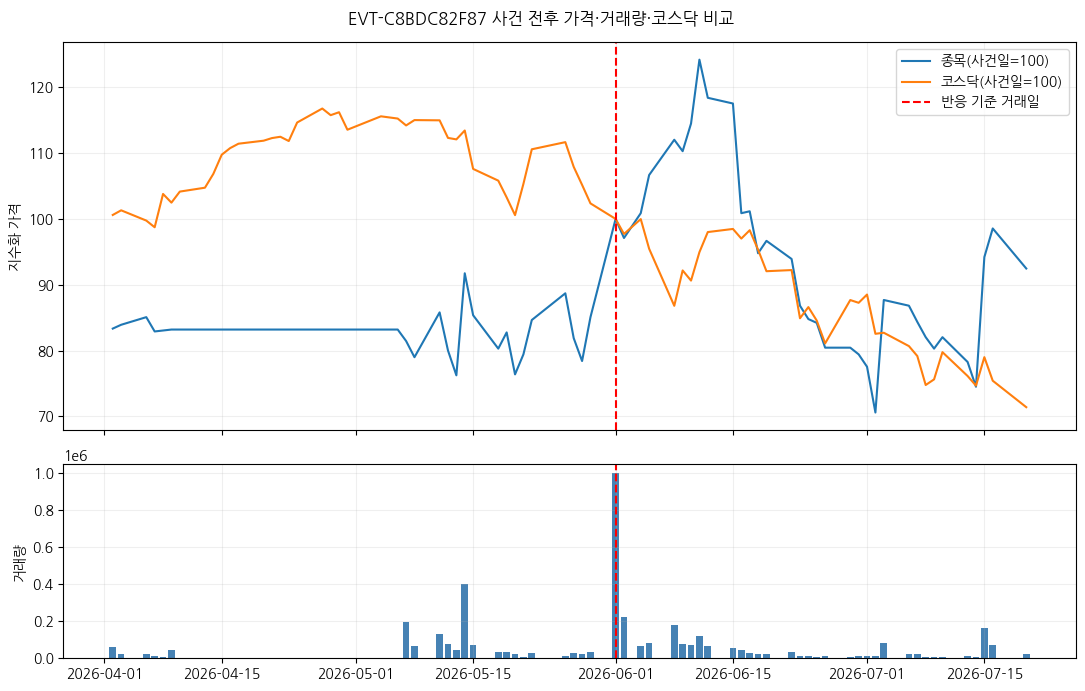

In [ ]:
def show_event_detail(event_id):
    matched = final_df[final_df["event_id"] == event_id]
    if matched.empty:
        raise KeyError(f"존재하지 않는 event_id: {event_id}")

    event = matched.iloc[0]
    history = market_history_by_event.get(event_id, pd.DataFrame())

    print("사건 ID:", event_id)
    print("종목명:", event["stock_name"])
    print("언급 기준시각:", event["event_anchor_at"])
    print("언급 세션:", event["mention_session"])
    print("반응 기준 거래일:", event["market_event_date"])
    print("상태:", event["pattern_status"])
    print("근거:", " / ".join(event["reason_badges"]))
    print(
        "시가총액:",
        f"{event['market_cap_krw'] / 1e8:,.1f}억 원",
        f"({market_cap_basis}, {market_cap_reference_date:%Y-%m-%d})",
    )

    detail_disclosures = event_disclosures_df[
        event_disclosures_df["event_id"] == event_id
    ]
    detail_news = event_news_df[
        event_news_df["event_id"] == event_id
    ] if not event_news_df.empty else pd.DataFrame()

    print("\n공시")
    if detail_disclosures.empty:
        print(event["disclosure_status"])
    else:
        print(
            detail_disclosures[
                ["report_nm", "rcept_dt", "dart_link"]
            ].to_string(index=False)
        )

    print("\n뉴스")
    if detail_news.empty:
        print(event["news_status"])
    else:
        print(
            detail_news[
                ["pubDate_kst", "title", "press_domain", "link"]
            ].to_string(index=False)
        )

    if (
        history is None
        or history.empty
        or pd.isna(event["market_event_date"])
    ):
        print("\n시장 시계열 데이터가 없어 그래프를 생략합니다.")
        return

    chart = history.copy().sort_values("Date")
    event_date = pd.Timestamp(event["market_event_date"])
    event_positions = np.where(chart["Date"] >= event_date)[0]
    base_index = int(event_positions[0]) if len(event_positions) else 0
    base_stock = chart.iloc[base_index]["Close"]
    base_market = chart.iloc[base_index]["IndexClose"]
    chart["StockIndexed"] = chart["Close"] / base_stock * 100
    chart["MarketIndexed"] = (
        chart["IndexClose"] / base_market * 100
    )

    figure, axes = plt.subplots(
        2,
        1,
        figsize=(11, 7),
        sharex=True,
        gridspec_kw={"height_ratios": [2, 1]},
    )
    axes[0].plot(
        chart["Date"],
        chart["StockIndexed"],
        label="종목(사건일=100)",
    )
    axes[0].plot(
        chart["Date"],
        chart["MarketIndexed"],
        label="코스닥(사건일=100)",
    )
    axes[0].axvline(
        event_date,
        color="red",
        linestyle="--",
        label="반응 기준 거래일",
    )
    axes[0].set_ylabel("지수화 가격")
    axes[0].legend()
    axes[0].grid(alpha=0.2)

    axes[1].bar(
        chart["Date"],
        chart["Volume"],
        color="steelblue",
    )
    axes[1].axvline(
        event_date,
        color="red",
        linestyle="--",
    )
    axes[1].set_ylabel("거래량")
    axes[1].grid(alpha=0.2)

    figure.suptitle(
        f"{event_id} 사건 전후 가격·거래량·코스닥 비교"
    )
    plt.tight_layout()
    plt.show()

if len(final_df):
    selected_event_id = final_df.iloc[0]["event_id"]
    show_event_detail(selected_event_id)
else:
    print("상세 표시할 사건이 없습니다.")


## 11. 결과 저장

목록용 CSV에는 익명 사건 ID만 저장합니다. Excel에는 목록, 상세 사건, 뉴스, 공시, 시장 시계열, 설정값을
시트별로 나눠 저장합니다. 리스트 형태의 근거 배지는 파일 저장 직전에 문자열로 변환합니다.


In [ ]:
OUTPUT_CSV = Path("telegram_fds_event_overview.csv")
OUTPUT_XLSX = Path("telegram_fds_event_dashboard.xlsx")

def stringify_lists(frame):
    result = frame.copy()
    for column in result.columns:
        result[column] = result[column].map(
            lambda value: (
                "; ".join(map(str, value))
                if isinstance(value, list)
                else value
            )
        )
    return result

def prepare_for_excel(frame):
    # Excel은 timezone-aware datetime을 직접 저장하지 못합니다.
    # 계산용 데이터는 유지하고, 내보내는 복사본에서만 ISO 문자열로 변환합니다.
    result = stringify_lists(frame)
    for column in result.columns:
        if isinstance(result[column].dtype, pd.DatetimeTZDtype):
            result[column] = result[column].astype(str)
        # openpyxl은 =, +, -, @로 시작하는 문자열을 수식으로 해석할 수 있습니다.
        # 외부에서 수집한 뉴스·공시 문장은 항상 텍스트로 저장해 수식 주입과 #NAME?을 막습니다.
        result[column] = result[column].map(
            lambda value: (
                "'" + value
                if isinstance(value, str)
                and value.startswith(("=", "+", "-", "@"))
                else value
            )
        )
    return result

anonymous_export_df = stringify_lists(dashboard_events_df)
detail_export_df = stringify_lists(final_df)

market_history_frames = [
    frame
    for frame in market_history_by_event.values()
    if frame is not None and not frame.empty
]
market_history_export_df = (
    pd.concat(market_history_frames, ignore_index=True)
    if market_history_frames
    else pd.DataFrame(
        columns=[
            "event_id", "ticker", "Date", "Close", "Volume",
            "IndexClose",
        ]
    )
)

settings_df = pd.DataFrame(
    [
        ["notebook_version", "v2.3"],
        ["analysis_start_kst", ANALYSIS_START_KST.isoformat()],
        ["analysis_end_kst", ANALYSIS_END_KST.isoformat()],
        ["crawl_start_kst", CRAWL_START_KST.isoformat()],
        ["crawl_end_kst", CRAWL_END_KST.isoformat()],
        ["cache_directory", str(CACHE_DIR)],
        [
            "google_drive_cache",
            USE_GOOGLE_DRIVE_CACHE,
        ],
        ["target_market", TARGET_MARKET],
        [
            "target_max_market_cap_krw",
            TARGET_MAX_MARKET_CAP_KRW,
        ],
        ["market_cap_basis", market_cap_basis],
        [
            "market_cap_reference_date",
            market_cap_reference_date.isoformat(),
        ],
        ["event_gap_hours", EVENT_GAP_HOURS],
        ["event_max_span_hours", EVENT_MAX_SPAN_HOURS],
        ["market_close_kst", "15:30"],
        ["min_baseline_rows", MIN_BASELINE_ROWS],
        ["min_baseline_active_days", MIN_BASELINE_ACTIVE_DAYS],
        ["min_event_active_days", MIN_EVENT_ACTIVE_DAYS],
        ["volume_ratio_threshold", VOLUME_RATIO_THRESHOLD],
        ["volume_robust_z_threshold", VOLUME_ROBUST_Z_THRESHOLD],
        [
            "event_abnormal_rise_threshold_pct",
            EVENT_ABNORMAL_RISE_THRESHOLD_PCT,
        ],
        [
            "relative_drop_threshold_pct",
            RELATIVE_DROP_THRESHOLD_PCT,
        ],
        [
            "drawdown_threshold_pct",
            DRAWDOWN_THRESHOLD_PCT,
        ],
        [
            "interpretation_limit",
            "불법·사기·시세조종·우량/부실·매수/매도를 판정하지 않음",
        ],
    ],
    columns=["setting", "value"],
)

anonymous_export_df.to_csv(
    OUTPUT_CSV,
    index=False,
    encoding="utf-8-sig",
)

with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:
    prepare_for_excel(anonymous_export_df).to_excel(
        writer,
        sheet_name="익명사건목록",
        index=False,
    )
    prepare_for_excel(detail_export_df).to_excel(
        writer,
        sheet_name="사건상세",
        index=False,
    )
    prepare_for_excel(pattern_group_comparison_df).to_excel(
        writer,
        sheet_name="패턴그룹비교",
        index=False,
    )
    prepare_for_excel(data_quality_summary_df).to_excel(
        writer,
        sheet_name="데이터품질",
        index=False,
    )
    prepare_for_excel(short_name_filter_summary_df).to_excel(
        writer,
        sheet_name="짧은종목명필터",
        index=False,
    )
    prepare_for_excel(event_news_df).to_excel(
        writer,
        sheet_name="뉴스",
        index=False,
    )
    prepare_for_excel(event_disclosures_df).to_excel(
        writer,
        sheet_name="공시",
        index=False,
    )
    prepare_for_excel(market_history_export_df).to_excel(
        writer,
        sheet_name="시장시계열",
        index=False,
    )
    prepare_for_excel(settings_df).to_excel(
        writer,
        sheet_name="설정및한계",
        index=False,
    )

    # 결과표를 바로 검토할 수 있도록 공통 헤더·필터·고정행·열 너비를 적용합니다.
    from openpyxl.styles import Alignment, Font, PatternFill
    from openpyxl.utils import get_column_letter

    header_fill = PatternFill(
        fill_type="solid",
        fgColor="1F4E78",
    )
    header_font = Font(
        color="FFFFFF",
        bold=True,
    )
    long_text_widths = {
        "channels": 30,
        "message_tags": 30,
        "sample_messages": 70,
        "reason_badges": 55,
        "title": 45,
        "description": 60,
        "combined_text": 60,
        "link": 50,
        "report_nm": 45,
        "dart_link": 50,
        "value": 45,
    }

    for worksheet in writer.book.worksheets:
        worksheet.freeze_panes = "A2"
        worksheet.auto_filter.ref = worksheet.dimensions
        worksheet.row_dimensions[1].height = 24

        for cell in worksheet[1]:
            cell.fill = header_fill
            cell.font = header_font
            cell.alignment = Alignment(
                horizontal="center",
                vertical="center",
            )

        sample_last_row = min(worksheet.max_row, 200)
        for column_index in range(1, worksheet.max_column + 1):
            header = str(
                worksheet.cell(1, column_index).value or ""
            )
            if header in long_text_widths:
                width = long_text_widths[header]
            else:
                sampled_lengths = [
                    len(str(worksheet.cell(row, column_index).value or ""))
                    for row in range(1, sample_last_row + 1)
                ]
                width = min(max(sampled_lengths, default=8) + 2, 28)
                width = max(width, 10)
            worksheet.column_dimensions[
                get_column_letter(column_index)
            ].width = width

print("저장 완료:", OUTPUT_CSV, OUTPUT_XLSX)

try:
    from google.colab import files

    files.download(str(OUTPUT_CSV))
    files.download(str(OUTPUT_XLSX))
except ImportError:
    print(
        "Colab 환경이 아니므로 자동 다운로드를 생략합니다."
    )


저장 완료: telegram_fds_event_overview.csv telegram_fds_event_dashboard.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12. 해석 제한과 다음 검증 항목

1. 시가총액 300억 원 미만은 위험 기준이 아니라 분석 대상 축소 기준입니다.
2. 거래량·가격·하락 임계값은 표본 분포를 확인하기 전의 실험값입니다.
3. 공시 미확인은 공시 부재, 허위 기사, 부실기업 또는 인과관계 부재를 뜻하지 않습니다.
4. 유사 기사 반복과 보도자료성 표현은 기사 작성 경위나 조작 여부를 증명하지 않습니다.
5. 네이버 뉴스 검색 결과 수 제한으로 과거 사건의 기사가 누락될 수 있습니다.
6. 현재 시가총액으로 과거 사건을 선정하면 생존편향과 시점 불일치가 발생할 수 있습니다.
7. 거래정지·신규 상장·액면분할·증자·수정주가에 따라 시장 데이터가 왜곡될 수 있습니다.
8. 공개 Telegram 메시지와 실제 종목명 표시는 법무·개인정보 검토가 필요합니다.

다음 단계에서는 실제 6월 표본으로 사건 수, 거래량 배율, 사후 상대수익률, 최대 낙폭의 분포를 먼저
확인하고 임계값과 사건 간격을 조정해야 합니다. 사용자 테스트에서는 상태명이 정상·불법 판정이나 투자
추천으로 오해되지 않는지도 함께 확인합니다.
